# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


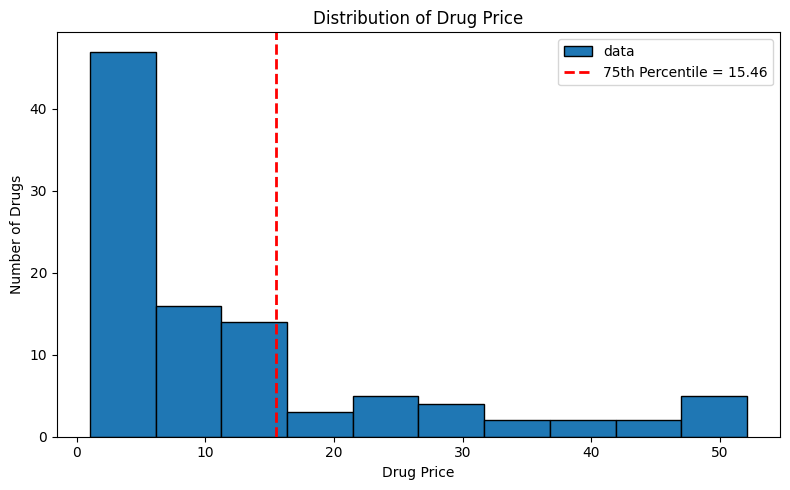

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist(edgecolor = "black", figsize = (8, 5))
plt.title("Distribution of Drug Price")
plt.xlabel("Drug Price")
plt.ylabel("Number of Drugs")
q75_price = df["data"].quantile(q = 0.75)
plt.axvline(q75_price, color = "red", linestyle="--", linewidth=2, label=f"75th Percentile = {q75_price:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

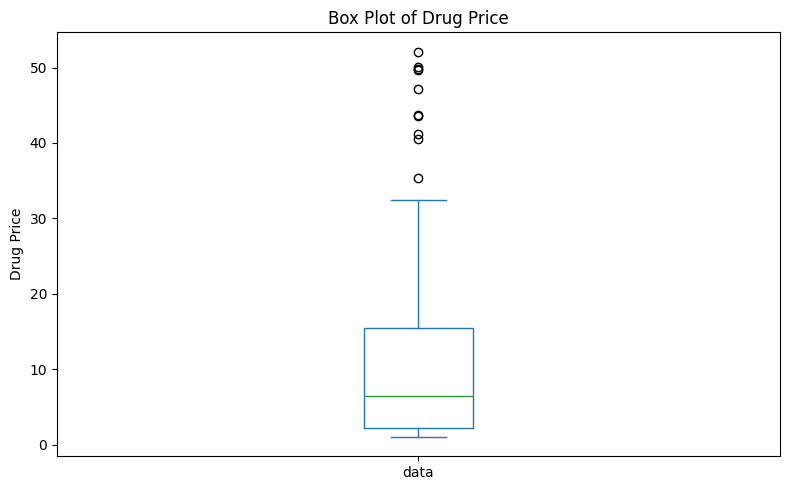

In [3]:
df.plot.box(figsize = (8, 5))
plt.title("Box Plot of Drug Price")
plt.ylabel("Drug Price")
plt.tight_layout()
plt.show()


The histogram and boxplot show the same drug price data, but they highlight different aspects of the distribution.  

<u>**histogram**</u>   

**pros**  
- The histogram is useful because it shows the overall shape of the data.  
We can see that most drug prices are concentrated at the lower end, while only a small number of drugs are much more expensive.  
This makes the right-skewed distribution easy to understand.  
- The histogram makes that context easier to see. It shows that most drugs are clustered at low prices, and only a few drugs are much more expensive. So the viewer can understand the full story  
  
**cons**  
- one weakness of the histogram is that it summarizes the data into bins, so we cannot see the exact individual prices.  
- the appearance of the distribution can change depending on the bin size. If the bins are too wide, important details may be hidden; if the bins are too narrow, the graph may look noisy.  
   

<u>**boxplot**</u> 

**pros**  
- The boxplot is useful because it gives a quick statistical summary of the data. It shows the median, the middle 50% of prices, the spread, and the high-price outliers. This makes it easy to identify that there are several unusually expensive drugs.  
  
**cons**    
- The boxplot does not show the full shape of the distribution as clearly as the histogram. It hides details about how many prices fall into each range.
____________________________________________________________________________
If I had to choose one, I would choose the histogram because the question is about understanding how the more expensive drugs compare with the rest of the prices. The histogram gives better context by showing that most prices are low and that the expensive drugs form a long right tail.  
The boxplot is helpful for identifying outliers, but the histogram makes that context easier to see and tells the overall story more clearly.

To improve the formatting, I would add a clear title, label the x-axis as “Drug Price” and the y-axis as “Number of Drugs,” remove the unnecessary legend, and add a vertical line for the 75th percentile.  
I would also make the boxplot horizontal so the price scale is easier to read.  
If possible, I would show both plots together because the histogram explains the distribution and the boxplot highlights the outliers.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
# impoort necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## **Week 4 Analysis: Distribution and Visualization**
For Week 4, I used the cleaned versions of the project datasets from the previous cleaning step. The goal of this section is to explore the distributions of important numeric and categorical variables using histograms, histogram variants, grouped visualizations, bar plots, and summary statistics.

This analysis focuses on understanding the overall shape of distributions, identifying possible outliers, comparing distributions across groups, checking minimum and maximum values, and evaluating whether the data appear usable for further EDA and project analysis.

### **Dataset 1: E-commerce User Behavior**

This dataset contains customer demographic information, order and purchase details, and online engagement variables.

It includes information such as customer age, segment, region, product category, sales, profit, shipping cost, browsing time, likes, shares, and add-to-cart behavior.

In this section, I use the cleaned EDA version of the dataset, `df_behavior_eda`, to explore important numeric and categorical variables related to customer behavior, purchases, and online engagement.

#### **Dataset 1 Column Descriptions**

- `Customer ID`: Unique identifier for each customer.

- `Order ID`: Unique identifier for each order.

- `Order Date`: Date when the order was placed.

- `Age`: Customer age.

- `Segment`: Customer segment, such as Consumer, Corporate, or Home Office.

- `Country`: Customer country.

- `Region`: Customer region.

- `Gender`: Customer gender.

- `Education`: Customer education level.

- `Marital Status`: Customer marital status.

- `Months`: Month related to the order or customer activity.

- `Sales`: Sales amount for the order or product interaction.

- `Quantity`: Number of items purchased.

- `Discount`: Discount rate applied to the order.

- `Profit`: Profit amount from the order or product.

- `Shipping Cost`: Cost of shipping for the order.

- `Ship Mode`: Shipping method used for the order.

- `Product Category`: Category of the purchased or viewed product.

- `Order Priority`: Priority level of the order.

- `Browsing Time`: Time the customer spent browsing.

- `Like`: Binary engagement variable showing whether the customer liked the item; 1 means yes, 0 means no.

- `Share`: Binary engagement variable showing whether the customer shared the item; 1 means yes, 0 means no.

- `Add to Cart`: Binary engagement variable showing whether the customer added the item to cart; 1 means yes, 0 means no.

#### **1.1 load and check**

In [5]:
# Load the cleaned dataset from the previous cleaning step
df_behavior = pd.read_pickle("data/df_behavior_eda.pkl")

# Quick check
df_behavior.shape

(51207, 27)

In [6]:
df_behavior.head(5)

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,...,140.0,2.0,0.05,46.0,4.6,Medium,14.7,1,1,1
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,...,211.0,3.0,0.03,112.0,11.2,Medium,15.0,0,0,1
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,...,117.0,5.0,0.01,31.2,3.1,Critical,19.9,1,1,1
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,...,118.0,2.0,0.05,26.2,2.6,High,15.8,1,1,1
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,...,250.0,1.0,0.04,160.0,16.0,Critical,18.1,1,1,1


In [7]:
df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51207 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          51207 non-null  object        
 1   Customer Name        51207 non-null  object        
 2   Segment              51207 non-null  object        
 3   City                 51207 non-null  object        
 4   State                51207 non-null  object        
 5   Country              51207 non-null  object        
 6   Region               51207 non-null  object        
 7   Gender               51207 non-null  object        
 8   Age                  51207 non-null  int64         
 9   Education            51207 non-null  object        
 10  Marital Status       51207 non-null  object        
 11  Order ID             51207 non-null  object        
 12  Order Date           51207 non-null  datetime64[ns]
 13  Months               51207 non-null 

#### **1.2 Selecting Columns for Distribution Analysis**

For this analysis, I selected numeric columns that are useful for histograms and distribution plots, and categorical columns that are useful for bar plots and grouped comparisons.

In [8]:
# Select useful numeric and categorical columns for Week 4 visual analysis
numeric_cols_behavior = ["Age","Sales","Quantity","Discount","Profit","Shipping Cost","Browsing Time (min)"]

categorical_cols_behavior = ["Segment","Region","Gender","Education","Marital Status","Ship Mode","Product Category","Order Priority"]

binary_cols_behavior = ["Like","Share","Add to Cart"]

print("Numeric columns:")
print(numeric_cols_behavior)

print("\nCategorical columns:")
print(categorical_cols_behavior)

print("\nBinary columns:")
print(binary_cols_behavior)

Numeric columns:
['Age', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Browsing Time (min)']

Categorical columns:
['Segment', 'Region', 'Gender', 'Education', 'Marital Status', 'Ship Mode', 'Product Category', 'Order Priority']

Binary columns:
['Like', 'Share', 'Add to Cart']


The numeric columns will be used for histograms and distribution plots. The categorical columns will be used for bar plots and grouped comparisons. The binary engagement columns are kept separate because they only contain 0 and 1 values.

#### **1.3 Summary Statistics for Selected Numeric Variables**

Before creating histograms, I summarized the selected numeric variables using mean, median, mode, minimum, and maximum values. This helps understand the center, range, and possible spread of each distribution.

In [9]:
# Summary statistics for selected numeric variables

summary_stats_behavior = df_behavior[numeric_cols_behavior].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T

summary_stats_behavior = summary_stats_behavior.rename(columns={"<lambda>": "mode"})

summary_stats_behavior

,mean,median,mode,min,max
Age,31.308005,28.00,18.00,18.00,70.00
Sales,156.421310,159.00,228.00,33.00,250.00
Quantity,2.997481,3.00,3.00,1.00,5.00
Discount,0.029971,0.03,0.03,0.01,0.05
Profit,72.718962,67.00,17.00,0.50,167.50
Shipping Cost,7.272457,6.70,2.10,0.10,16.80
Browsing Time (min),17.283073,16.50,7.40,1.00,40.00


The summary statistics show that the selected numeric variables have reasonable ranges.  
- Age ranges from 18 to 70, with a mean of about 31.3 and a median of 28.

- Sales range from 33 to 250, with the mean and median being close to each other, which suggests that Sales may not be strongly skewed.  

- Quantity is centered around 3, with values ranging from 1 to 5.  

- Discount ranges from 0.01 to 0.05 and is centered around 0.03.
  
- Profit, Shipping Cost, and Browsing Time have wider ranges, so their distributions should be checked visually with histograms and boxplots to better understand their shape and possible outliers.

#### **1.4 Histograms for Selected Numeric Variables**

I created histograms for the selected numeric variables to examine the overall shape of each distribution. These plots help identify whether the variables appear normal, skewed, uniform, or concentrated around certain values.

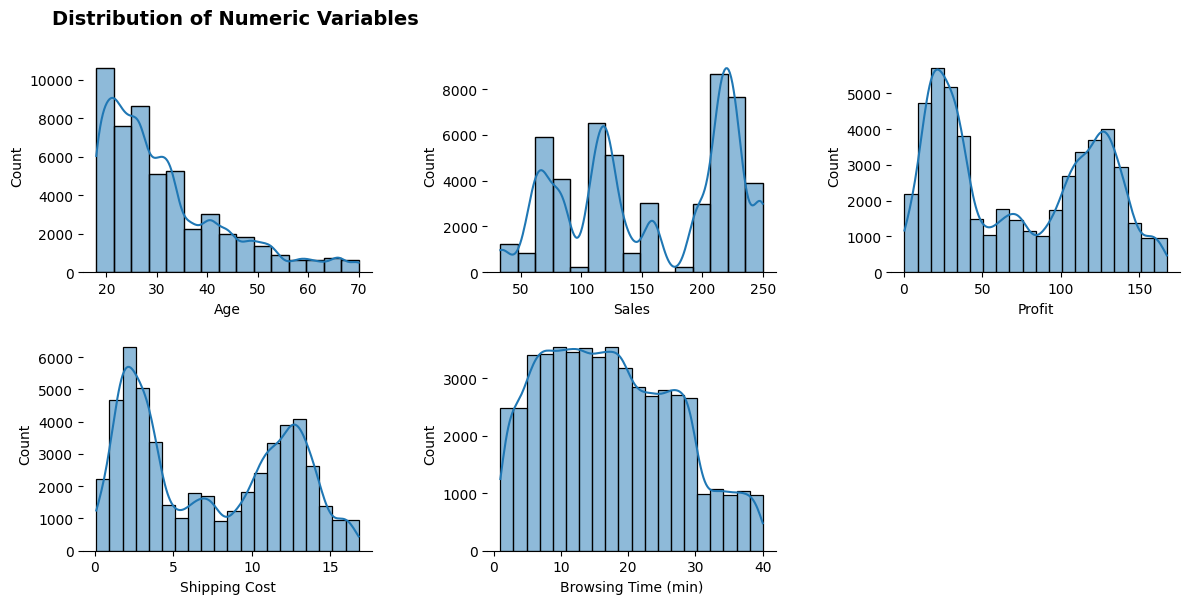

In [10]:
# Histograms for selected numeric variables
bin_settings = {"Age": 15,"Sales": 15,"Profit": 20,"Shipping Cost": 20,"Browsing Time (min)": 20}
cols = 3
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_behavior, x=col, bins=bin_settings[col], kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)
# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.3)
plt.show()

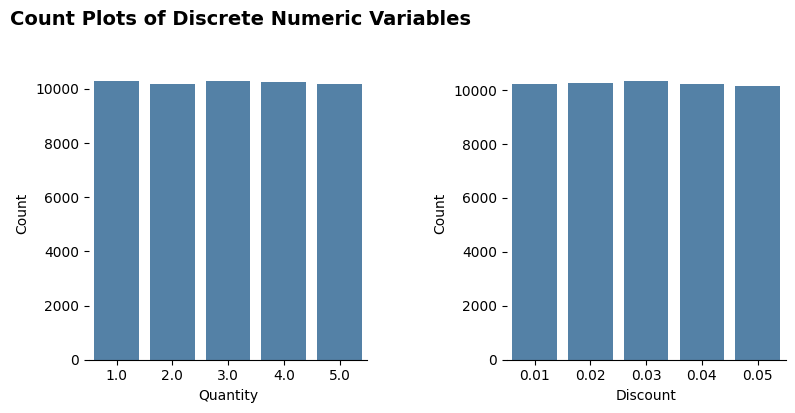

In [11]:
# countplots for selected numeric variables that are discrete (Quantity and Discount)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.countplot(data=df_behavior, x="Quantity", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Count")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_visible(False)
sns.countplot(data=df_behavior, x="Discount", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Count")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

fig.suptitle("Count Plots of Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

The histograms show that the selected numeric variables have different distribution shapes and do not all follow a normal distribution.

- Age is right-skewed. Most customers are concentrated in younger age groups, especially between about 18 and 35 years old, and the number of customers decreases as age increases. This suggests that the dataset represents a relatively young customer base.

- Sales does not appear normally distributed. Instead, it shows several peaks, especially around the lower-middle sales range, around 110–130, and again around 210–230. This suggests that sales values may be clustered around common price levels or product/order groups rather than being smoothly distributed.

- Profit also does not follow a normal distribution. It appears to have a bimodal pattern, with one concentration around lower profit values and another around higher profit values. This may indicate that the dataset contains different types of orders or product groups with different profit levels.

- Shipping Cost shows a similar bimodal pattern. There is one group of orders with lower shipping costs and another group with higher shipping costs. This pattern may be related to differences in product category, order size, shipping mode, or region.

- Browsing Time is more spread out across the range, with many customers spending between about 5 and 30 minutes browsing. The frequency decreases after about 30 minutes, so the distribution is not perfectly normal. It suggests that most users spend a moderate amount of time browsing, while fewer users spend very long sessions.

- Quantity and Discount were plotted separately because they are discrete variables with only a few possible values. Quantity ranges from 1 to 5 and appears fairly evenly distributed across those values.  
- Discount ranges from 0.01 to 0.05 and also appears almost evenly distributed. These variables do not behave like continuous variables, so count-style plots are more appropriate than regular histograms with KDE curves.

- Overall, the distributions look usable for further EDA. However, several variables are not normally distributed, and some variables such as Profit and Shipping Cost show clear grouped or bimodal patterns. These patterns are useful because they may reveal differences across customer segments, product categories, shipping modes, or regions in later analysis.

#### **1.5 Effect of Bin Size on Sales Histogram**

To understand how bin size affects the appearance of a histogram, I compared the Sales distribution using different numbers of bins. This helps show whether changing the bin width hides or reveals patterns in the data.

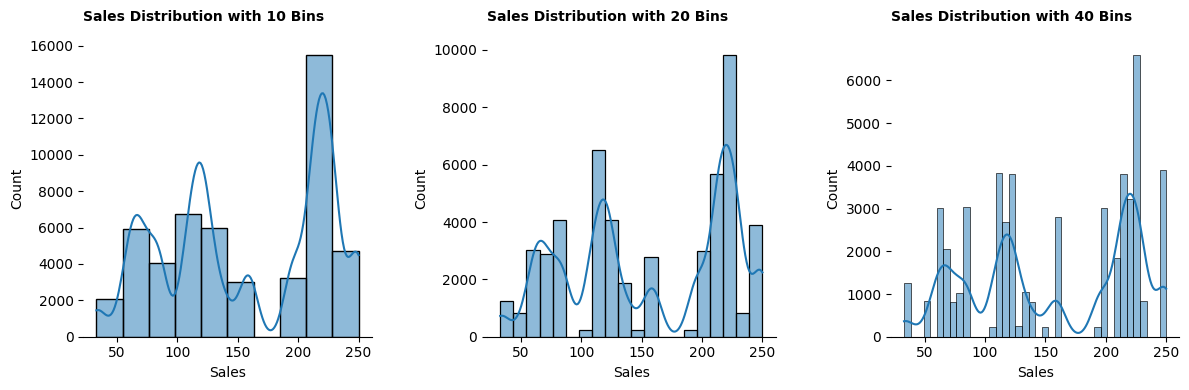

In [12]:
# Compare different bin sizes for Sales
bin_sizes = [10, 20, 40]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, bins in enumerate(bin_sizes):
    sns.histplot(data=df_behavior, x="Sales", bins=bins, kde=True, ax=axes[i])
    axes[i].set_title(f"Sales Distribution with {bins} Bins", loc="left", pad=14, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Sales")
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

Changing the bin size changes how the Sales histogram looks.  

With 10 bins, the chart is easier to read, but it hides some smaller details. We can still see that many sales values are around 200 to 230, but the smaller groups are not very clear.

With 20 bins, the chart gives a better balance. It is still readable, and it shows more details in the Sales distribution. We can see that Sales has several common ranges, such as around 60 to 80, 110 to 130, and 210 to 230.

With 40 bins, the chart shows even more detail, but it also becomes harder to read. The bars are more broken up, so the overall pattern is less smooth.

Overall, 20 bins seems like the best choice for the Sales histogram because it shows the main patterns without making the chart too busy.

#### **1.6 Boxplots and Outlier Check**

After reviewing the histograms, I used boxplots to check the spread of the main numeric variables and look for possible outliers.  
Histograms are useful for seeing the overall shape of a distribution, while boxplots are useful for identifying the median, spread, and values that are far from the rest of the data.

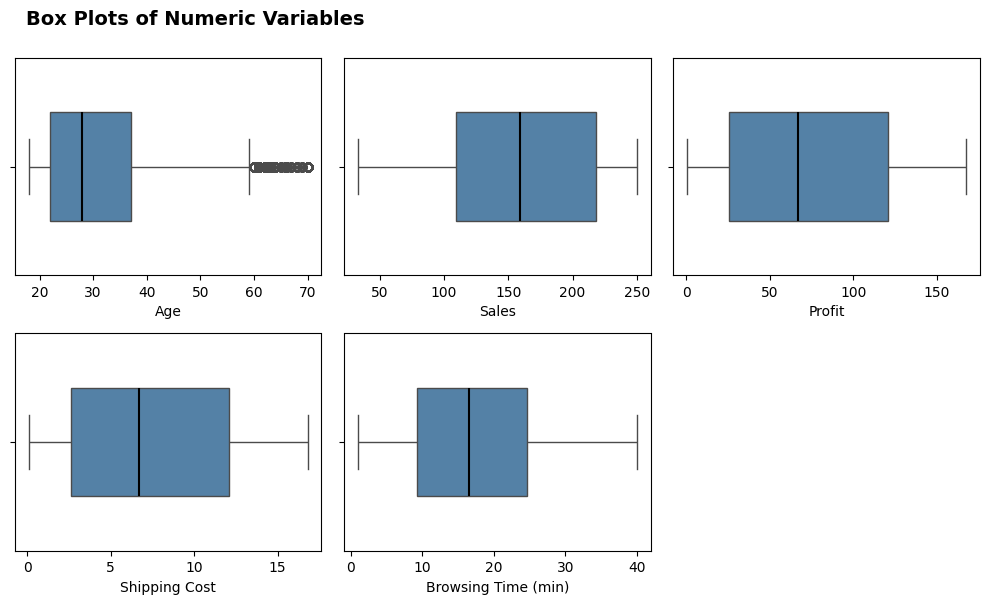

In [13]:
# Boxplots for main numeric variables

boxplot_cols_behavior = ["Age","Sales","Profit","Shipping Cost","Browsing Time (min)"]

cols = 3
rows = (len(boxplot_cols_behavior) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_behavior):
    sns.boxplot(data=df_behavior, x=col, ax=axes[i], color = "steelblue", medianprops={"color": "black", "linewidth": 1.5}, width=0.5)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.show()

The boxplots show that most numeric variables do not have major outlier problems.  

Sales, Profit, Shipping Cost, and Browsing Time stay within reasonable ranges and do not show clear extreme values.

Age is the only variable with visible high-end outliers, mostly around ages 60 to 70. These values are not invalid because they are still realistic customer ages.

#### **1.7 Bar Plots for Categorical Variables**

I created bar plots for the selected categorical variables to compare the number of records in each category. These plots help show which groups appear more often in the dataset.

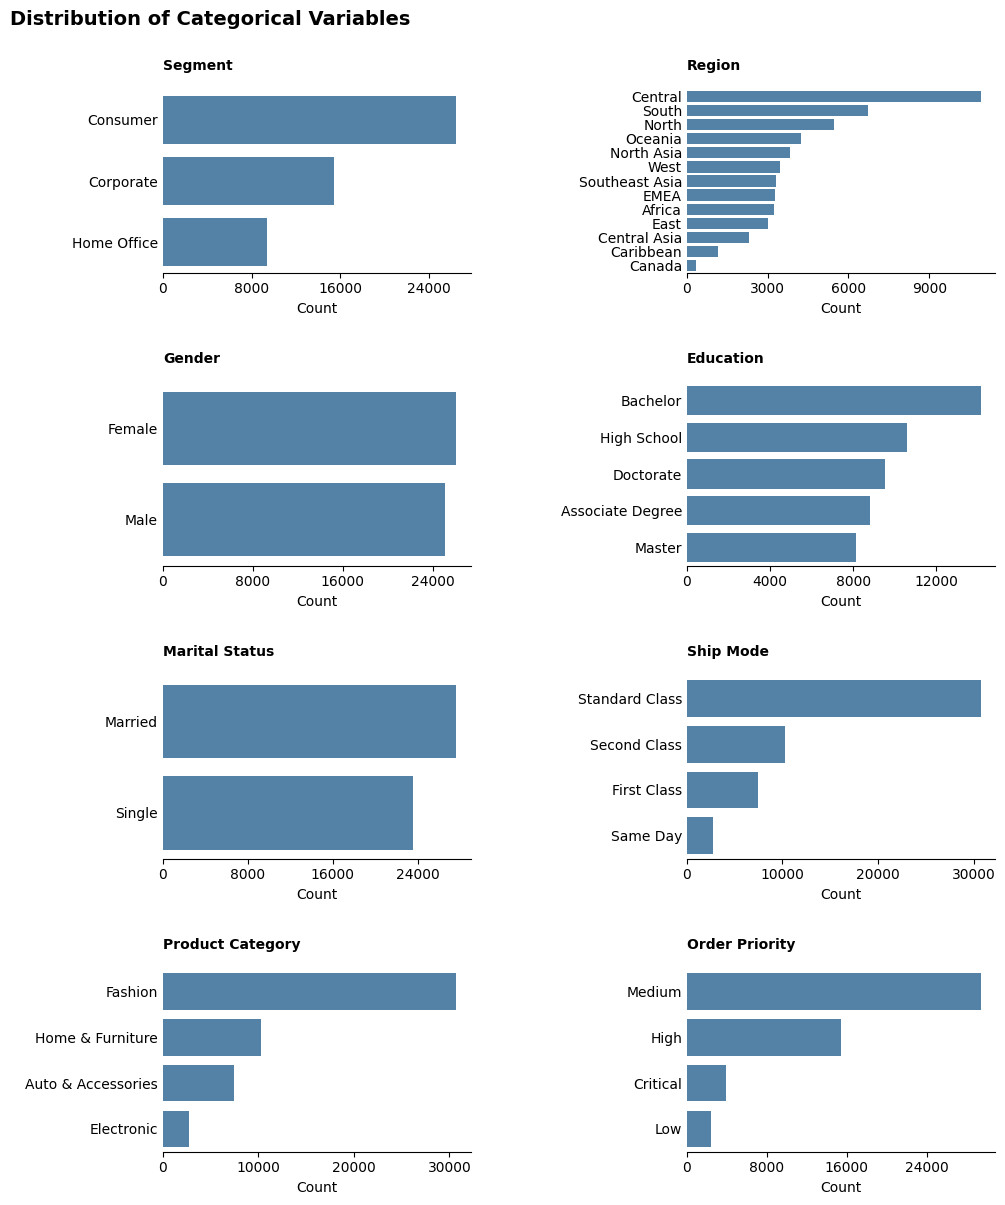

In [14]:
# Bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_behavior) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_behavior):
    order = df_behavior[col].value_counts().index
    
    sns.countplot(data=df_behavior, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=14, fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="y", length=0)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

    axes[i].xaxis.set_major_locator(MaxNLocator(nbins=4))
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.7, hspace=0.6)
plt.show();

The bar plots show that some categorical variables are more balanced than others.    
     
- The Segment variable is dominated by Consumer customers, followed by Corporate and Home Office. This suggests that the dataset mainly represents individual consumer behavior.

- For Region, Central has the highest number of records, followed by South and North. Other regions such as Canada and Caribbean have much smaller counts. This means regional representation is not evenly distributed across the dataset.

- Gender is almost balanced, with Female and Male having very similar counts.  
  
- Marital Status is also fairly balanced, although Married customers appear more often than Single customers.

- For Education, Bachelor is the most common group, followed by High School and Doctorate. The education categories are not perfectly balanced, but all groups have enough records for EDA.

- Ship Mode is strongly dominated by Standard Class, while Same Day has the smallest count. This suggests that most orders use regular shipping rather than faster shipping options.

- Product Category is also imbalanced. Fashion has the highest number of records by far, while Electronic has the lowest. This is important because later analysis of sales or engagement may be influenced by the large number of Fashion records.

- Order Priority is mostly Medium, followed by High, while Critical and Low are much less common.   
  
- Overall, the categorical variables are usable, but some variables such as Product Category, Ship Mode, Region, and Order Priority are clearly imbalanced across categories.

#### **1.8 Grouped Distribution Analysis**

##### **1.8.1 Sales by Product Category**  
To compare Sales across product categories, I used a KDE plot and a violin plot. The KDE plot shows the overall shape of the Sales distribution for each category, while the violin plot makes it easier to compare the spread and concentration of Sales values across categories.

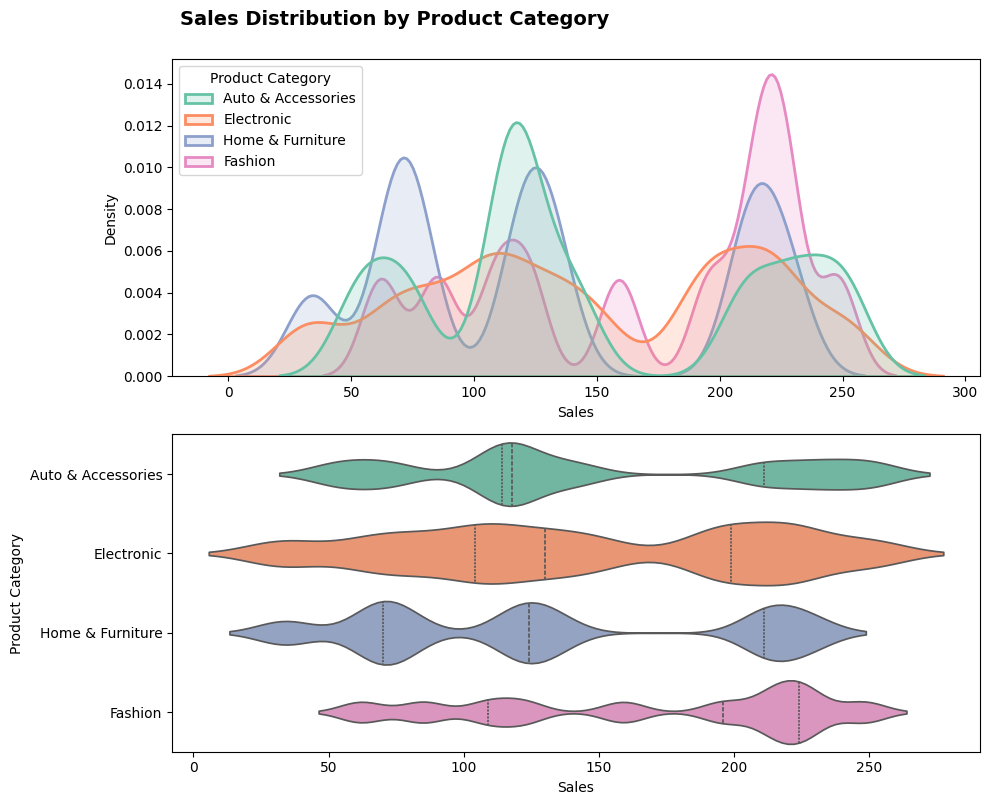

In [15]:
# KDE and violin plots for Sales by Product Category
fig, ax = plt.subplots(2,1, figsize = (10, 8))
ax = ax.flatten()

# KDE plot
sns.kdeplot(data=df_behavior, x="Sales", hue="Product Category", common_norm=False, fill=True, linewidth=2, alpha=0.2, palette= "Set2", ax=ax[0])
ax[0].set_xlabel("Sales")

# Violin plot
sns.violinplot(data=df_behavior, x="Sales", y="Product Category", hue="Product Category", inner="quartile", ax=ax[1], palette="Set2")
ax[1].set_xlabel("Sales")
ax[1].set_ylabel("Product Category")

fig.suptitle("Sales Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.4)
plt.tight_layout()
plt.show()

The Sales distribution changes across product categories.  

- Fashion has a strong concentration in the higher Sales range, especially around 210 to 230. This suggests that many Fashion records are clustered around higher sales values.  

- Home & Furniture and Auto & Accessories show more than one common Sales range, which suggests that Sales is not normally distributed within these categories.  

- Electronic appears more spread out across the Sales range and has a less sharp concentration compared with the other categories.

The violin plot also shows that the categories overlap, so Sales is not completely separated by Product Category. However, the shape, spread, and concentration of Sales values are different across categories.  

Overall, Product Category seems to help explain some of the multi-peak pattern seen in the overall Sales distribution.

##### **1.8.2 Profit Distribution by Product Category**

To compare Profit across product categories, I used a KDE plot and a violin plot. The KDE plot shows the overall shape of the Profit distribution for each product category, while the violin plot helps compare the spread and concentration of Profit values across categories.

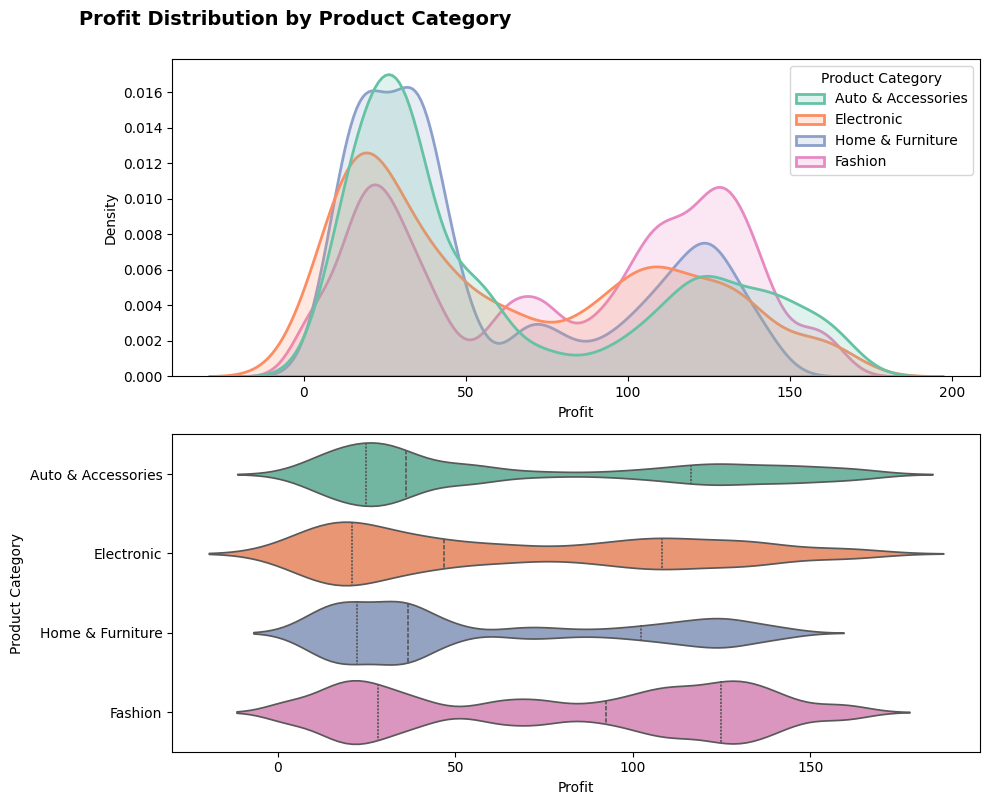

In [16]:
# KDE and violin plots for Profit by Product Category
fig, ax = plt.subplots(2,1, figsize = (10, 8))
ax = ax.flatten()

# KDE plot
sns.kdeplot(data=df_behavior, x="Profit", hue="Product Category", common_norm=False, fill=True, linewidth=2, alpha=0.2, palette= "Set2", ax=ax[0])
ax[0].set_xlabel("Profit")

# Violin plot
sns.violinplot(data=df_behavior, x="Profit", y="Product Category", hue="Product Category", inner="quartile", ax=ax[1], palette="Set2")
ax[1].set_xlabel("Profit")
ax[1].set_ylabel("Product Category")

fig.suptitle("Profit Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The Profit distribution changes across product categories, but the categories still overlap a lot.

- Most product categories show a clear low-profit concentration around 20 to 40. This means many records across different product categories have relatively low profit values.

- There is also a second concentration in the higher-profit range, especially around 110 to 140.  

- Fashion and Home & Furniture show stronger density in this higher-profit range, while Auto & Accessories also has values spread into higher profit levels.

- Electronic appears more spread out across the profit range, but it does not have one sharp peak. Its profit values are distributed across both lower and higher ranges.

The violin plot confirms that Profit is not completely separated by Product Category. However, the shape of the distributions suggests that some product categories have different profit patterns, especially between lower-profit and higher-profit ranges.

Overall, Product Category helps explain part of the grouped pattern in Profit, but it does not fully separate profit levels by itself.

##### **1.8.3 Browsing Time by Add to Cart**  
To compare browsing behavior across customer actions, I looked at the distribution of Browsing Time for users who added an item to the cart and users who did not.

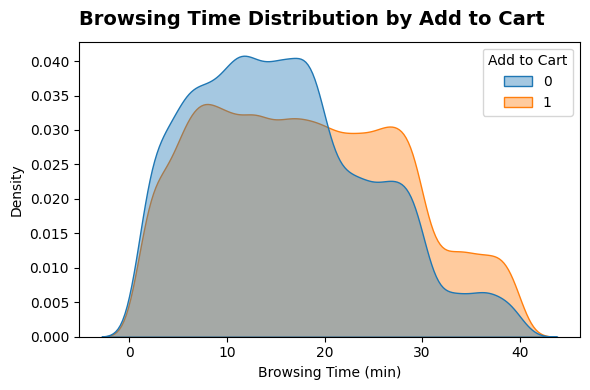

In [17]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_behavior, x="Browsing Time (min)", hue="Add to Cart", common_norm=False, fill=True, alpha=0.4)
plt.title("Browsing Time Distribution by Add to Cart", loc="left", fontsize=14, fontweight="bold", y=1, pad=12)
plt.xlabel("Browsing Time (min)")
plt.tight_layout()
plt.show()

The KDE plot compares browsing time for users who added an item to the cart and users who did not.  

The two distributions overlap a lot, which means browsing time alone does not clearly separate the two groups.

Users who did not add to cart are more concentrated around shorter to moderate browsing times, especially around 8 to 20 minutes.  

Users who added to cart have a slightly stronger presence in longer browsing times, especially around 20 to 30 minutes.

Overall, browsing time seems to have some relationship with add-to-cart behavior, but the separation is not strong.  
This means browsing time may be useful for understanding purchase intent, but it should be considered together with other variables such as product category, sales amount, discount, Like, and Share.

#### **1.9 Final Week 4 Conclusion for Dataset 1**

The Week 4 analysis shows that Dataset 1 is useful for understanding customer behavior, product-level sales patterns, and online engagement.

- The numeric variables do not all follow a normal distribution. Age is right-skewed, with most customers concentrated in younger age groups.  

- Sales shows multiple common ranges instead of one smooth normal shape.  

- Profit and Shipping Cost also show grouped or multi-peak patterns, which suggests that different types of orders or product groups may behave differently.

- Quantity and Discount behave more like discrete variables than continuous variables. Quantity ranges from 1 to 5, and Discount ranges from 0.01 to 0.05. Because they have only a few possible values, count-style plots were more useful for these variables than regular histograms with KDE curves.

- The bin size comparison for Sales showed that the appearance of a histogram can change based on the number of bins. With fewer bins, the distribution looks smoother but hides some details. With more bins, smaller patterns become more visible, but the chart can become harder to read.  
For this dataset, 20 bins gave a good balance between readability and detail.  

- The boxplots showed that most numeric variables do not have major outlier problems. Age has some high-end outliers, mostly around older customer ages, but these values are still realistic and do not appear to be data errors. Sales, Profit, Shipping Cost, and Browsing Time stay within reasonable ranges.

- The categorical bar plots showed that some variables are more balanced than others. Gender is almost balanced, and Marital Status is fairly balanced. However, Product Category is strongly dominated by Fashion, Ship Mode is dominated by Standard Class, and Order Priority is mostly Medium.  These imbalances are important to remember when comparing groups.

- The grouped distribution analysis showed that Sales and Profit patterns change across Product Category. Sales is not completely separated by product category, but the KDE and violin plots show different shapes and concentrations across categories.  
Profit also shows lower-profit and higher-profit ranges across product categories, so Product Category helps explain part of the grouped pattern in Profit.

- Browsing Time by Add to Cart showed a lot of overlap between users who added an item to the cart and users who did not.  
Users who added to cart appear slightly more present in some longer browsing-time ranges, but the separation is not strong. This suggests that Browsing Time may be related to Add to Cart behavior, but it is not enough by itself to explain purchase intent.

Overall, the dataset is useful for later analysis. The distributions are not perfectly normal, but the patterns are meaningful and can help support analysis of customer behavior, sales patterns, and engagement.

### **Dataset 2: Sales and Customer Insights**

- This dataset is customer-based. each row is a customer-level sales insight record, but it also includes information about the product connected to that customer record.

- It contains customer purchase behavior, churn probability, lifetime value, product category, region, season, and retention strategy information.  

- In this section, I use the cleaned version of the dataset to explore important numeric and categorical variables related to customer value, purchase patterns, churn risk, and retention strategy.  


#### **Dataset 2 Column Descriptions**


- `Customer_ID`: Unique identifier for each customer.

- `Product_ID`: Unique identifier for each product.

- `Transaction_ID`: Unique identifier for each transaction.

- `Purchase_Frequency`: Number of purchases made by the customer.

- `Average_Order_Value`: Average amount spent per order.

- `Most_Frequent_Category`: Product category the customer buys most often.

- `Time_Between_Purchases`: Average time between purchases, likely in days.

- `Region`: Customer’s geographic region.

- `Churn_Probability`: Estimated probability that the customer may not return, from 0 to 1.

- `Lifetime_Value`: Estimated total value or revenue from the customer.

- `Launch_Date`: Launch date of the product connected to the customer record.

- `Peak_Sales_Date`: Date when the product reached its highest sales activity.

- `Season`: Season related to the product’s peak sales activity.

- `Preferred_Purchase_Times`: Time of day when the customer usually prefers to purchase.

- `Retention_Strategy`: Strategy used to keep or retain the customer.

#### **2.1 load and check**

In [18]:
# Load the cleaned dataset from the previous cleaning step
df_sales = pd.read_pickle("data/df_sales_eda.pkl")

# Quick check
df_sales.shape

(10000, 15)

In [19]:
df_sales.head(5)

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [20]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_ID               10000 non-null  object        
 1   Product_ID                10000 non-null  object        
 2   Transaction_ID            10000 non-null  object        
 3   Purchase_Frequency        10000 non-null  int64         
 4   Average_Order_Value       10000 non-null  float64       
 5   Most_Frequent_Category    10000 non-null  object        
 6   Time_Between_Purchases    10000 non-null  int64         
 7   Region                    10000 non-null  object        
 8   Churn_Probability         10000 non-null  float64       
 9   Lifetime_Value            10000 non-null  float64       
 10  Launch_Date               10000 non-null  datetime64[ns]
 11  Peak_Sales_Date           10000 non-null  datetime64[ns]
 12  Season             

#### **2.2 Selecting Columns for Distribution Analysis**

For this analysis, I selected numeric columns that are useful for histograms and distribution plots, and categorical columns that are useful for bar plots and grouped comparisons. Identifier columns are not used as main visualization variables because they do not provide meaningful distributions.

In [21]:
numeric_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]
categorical_cols_sales = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]
identifier_cols_sales = ["Customer_ID","Product_ID","Transaction_ID"]

print("Numeric columns:")
print(numeric_cols_sales)

print("\nCategorical columns:")
print(categorical_cols_sales)

print("\nIdentifier columns:")
print(identifier_cols_sales)

Numeric columns:
['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

Categorical columns:
['Most_Frequent_Category', 'Region', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy']

Identifier columns:
['Customer_ID', 'Product_ID', 'Transaction_ID']


#### **2.3 Summary Statistics for Selected Numeric Variables**

In this step, I calculated summary statistics for the selected numeric variables. This helps compare the center and range of each distribution before creating histograms and other plots.

In [22]:
# Summary statistics for selected numeric variables

summary_stats_sales= df_sales[numeric_cols_sales].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T

summary_stats_sales = summary_stats_sales.rename(columns={"<lambda>": "mode"})

summary_stats_sales

,mean,median,mode,min,max
Purchase_Frequency,9.955700,10.00,1.00,1.00,19.00
Average_Order_Value,110.006022,109.93,26.74,20.01,199.96
Time_Between_Purchases,46.885300,47.00,74.00,5.00,89.00
Churn_Probability,0.501552,0.50,0.84,0.00,1.00
Lifetime_Value,5031.930567,5012.18,138.63,100.16,9999.76


The summary statistics show that the selected numeric variables have reasonable ranges.  

- Purchase_Frequency ranges from 1 to 19, with a mean of about 9.96 and a median of 10.  

- Average_Order_Value ranges from 20.01 to 199.96, and the mean and median are both close to 110.

- Time_Between_Purchases ranges from 5 to 89 days, with a mean and median around 47 days.  

- Churn_Probability ranges from 0 to 1, which is the expected range for a probability variable, and both the mean and median are close to 0.50.

- Lifetime_Value ranges from 100.16 to 9999.76, with a mean of about 5031.93 and a median of about 5012.18.  

- Overall, the mean and median values are close for most variables, so the center of the distributions appears balanced. The mode is less useful for continuous variables such as Average_Order_Value and Lifetime_Value, but it is included for comparison.

#### **2.4 Histograms for Selected Numeric Variables**

In this step, I created histograms for the selected numeric variables to understand the shape of each distribution. These plots help show whether the variables are roughly normal, skewed, uniform, discrete, or have multiple peaks.

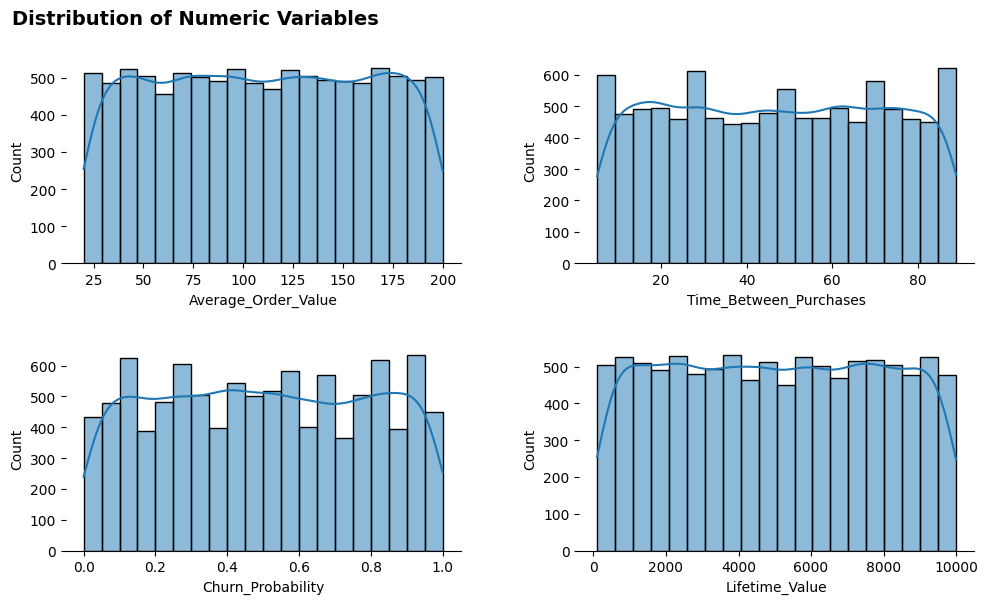

In [23]:
# Histograms for selected numeric variables
bin_settings = {"Average_Order_Value": 20, "Time_Between_Purchases": 20, "Churn_Probability": 20, "Lifetime_Value": 20}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_sales, x=col, bins=bin_settings[col], kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

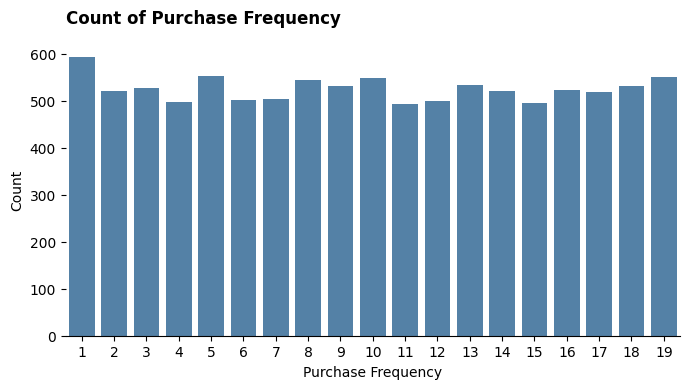

In [24]:
# countplots for selected numeric variables that are discrete (Purchase_Frequency)
plt.figure(figsize=(7, 4))
sns.countplot(data = df_sales, x="Purchase_Frequency", color="steelblue")
plt.title("Count of Purchase Frequency", fontweight="bold", pad=10, y=1.02, loc="left")
plt.xlabel("Purchase Frequency")
plt.ylabel("Count")

axes = plt.gca()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

- The histograms show that most selected numeric variables are spread fairly evenly across their ranges.

- Average_Order_Value ranges from about 20 to 200 and appears almost uniformly distributed. There is no strong skewness or clear single peak. This means customers are fairly evenly spread across low, medium, and high average order values.

- Time_Between_Purchases ranges from about 5 to 89 days and also looks fairly uniform. There is no clear concentration around one specific purchase interval.

- Churn_Probability ranges from 0 to 1 and is spread across the full probability range. The distribution does not show a strong concentration near only low-risk or high-risk customers.

- Lifetime_Value ranges from about 100 to 10,000 and also appears broadly uniform. Customers are distributed across low, medium, and high lifetime value levels.

- Purchase_Frequency is a discrete numeric variable, so I used a count plot instead of a regular histogram. The count plot shows that purchase frequency values from 1 to 19 are fairly balanced, with no single frequency dominating the dataset.

- Overall, the numeric variables in Dataset 2 do not appear normally distributed. They are mostly uniform or evenly spread across their possible ranges. No obvious extreme outliers are visible from these plots.

- The dataset appears usable for practicing distribution analysis and visualization, but the numeric variables look more evenly distributed than expected in real customer behavior data. This suggests that the dataset may be synthetic or generated rather than fully organic real-world transaction data.

#### **2.5 Boxplots and Outlier Check**

In this step, I used boxplots to check the spread of the selected numeric variables and look for possible outliers.

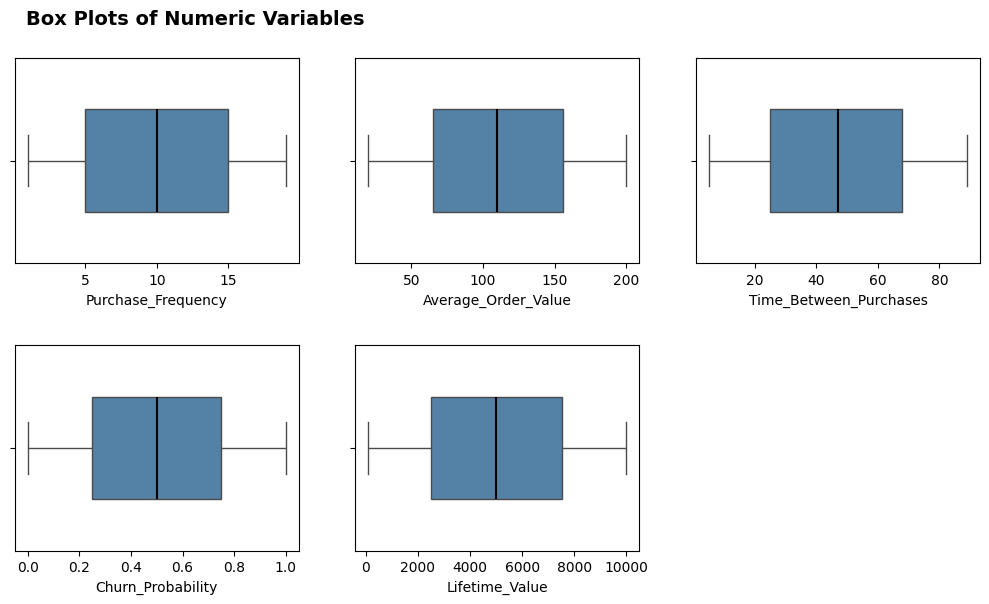

In [25]:
# boxplots for main numeric variables
boxplot_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]

cols = 3
rows = (len(boxplot_cols_sales) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_sales):
    sns.boxplot(data=df_sales, x=col, ax=axes[i], color = "steelblue", medianprops={"color": "black", "linewidth": 1.5}, width=0.5)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()


The boxplots show that the selected numeric variables have wide but reasonable ranges. The median values are close to the center of each box, which is consistent with the fairly balanced distributions observed in the histograms.

No obvious outliers are visible in the boxplots. Purchase_Frequency, Average_Order_Value, Time_Between_Purchases, Churn_Probability, and Lifetime_Value all stay within their expected ranges.

Because the values appear realistic and no extreme invalid points are shown, no observations need to be removed based on the boxplot analysis.

#### **2.6 Bar Plots for Categorical Variables**

In this step, I used bar plots to check the distribution of the selected categorical variables. These plots help show whether categories are balanced or whether some categories dominate the dataset.

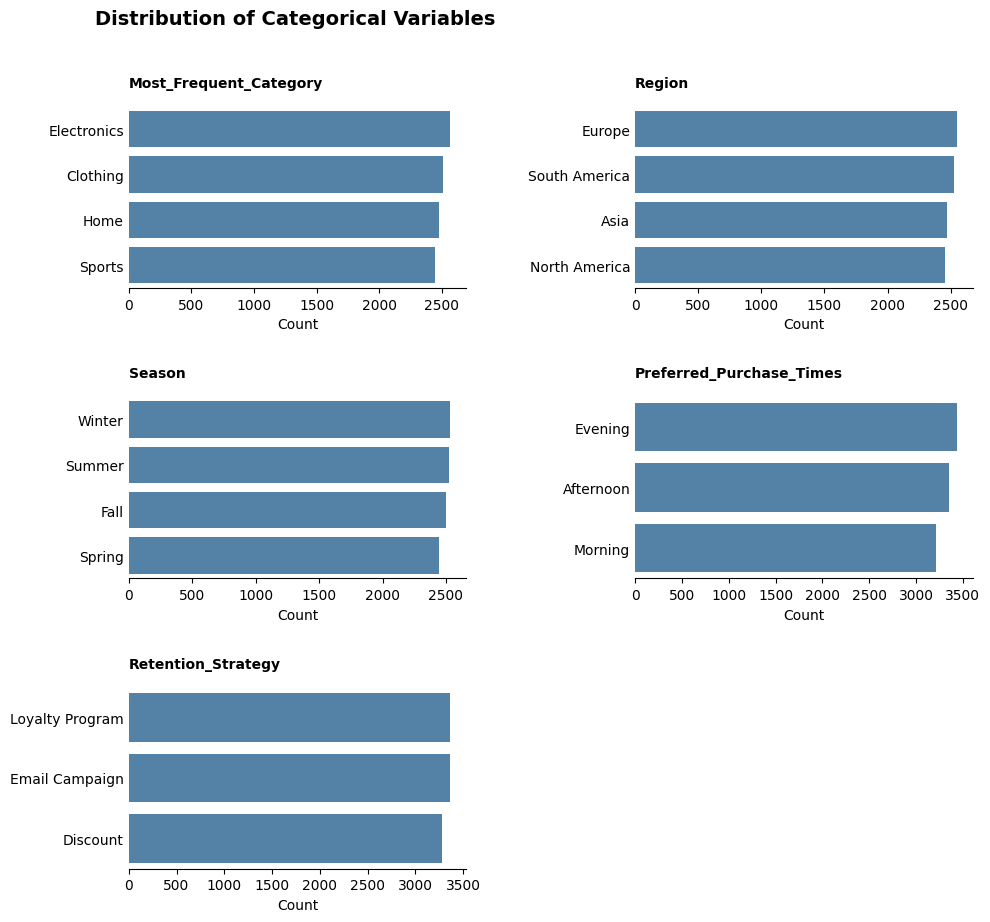

In [26]:
# bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_sales) + cols - 1) // cols
fig,axes = plt.subplots(rows, cols, figsize = (10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate (categorical_cols_sales):
    order = df_sales[col].value_counts().index
    sns.countplot(data=df_sales, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count") 
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_title(col, loc="left", pad=14, fontsize=10, fontweight="bold")
    axes[i].set_ylabel(None)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.6)
plt.show()

The bar plots show that the categorical variables are fairly balanced across their categories.

- Most_Frequent_Category is almost evenly distributed across Electronics, Clothing, Home, and Sports.  

- Region is also balanced across Europe, South America, Asia, and North America.   

- Season has a similar pattern, with Winter, Summer, Fall, and Spring appearing at close counts.

- Preferred_Purchase_Times shows a small difference, with Evening appearing slightly more often than Afternoon and Morning, but the difference is not large.  

- Retention_Strategy is also fairly balanced across Loyalty Program, Email Campaign, and Discount.

Overall, no categorical variable is heavily dominated by one category. This supports the earlier observation that Dataset 2 appears very evenly distributed and may be synthetic or generated for analysis practice.

#### **2.7 Grouped Distribution Analysis**

In this step, I created grouped distribution plots to compare important numeric variables across meaningful categories. The goal is to see whether churn risk, customer value, and spending behavior change across retention strategies or product categories.

##### **2.7.1 Churn Probability by Retention Strategy**

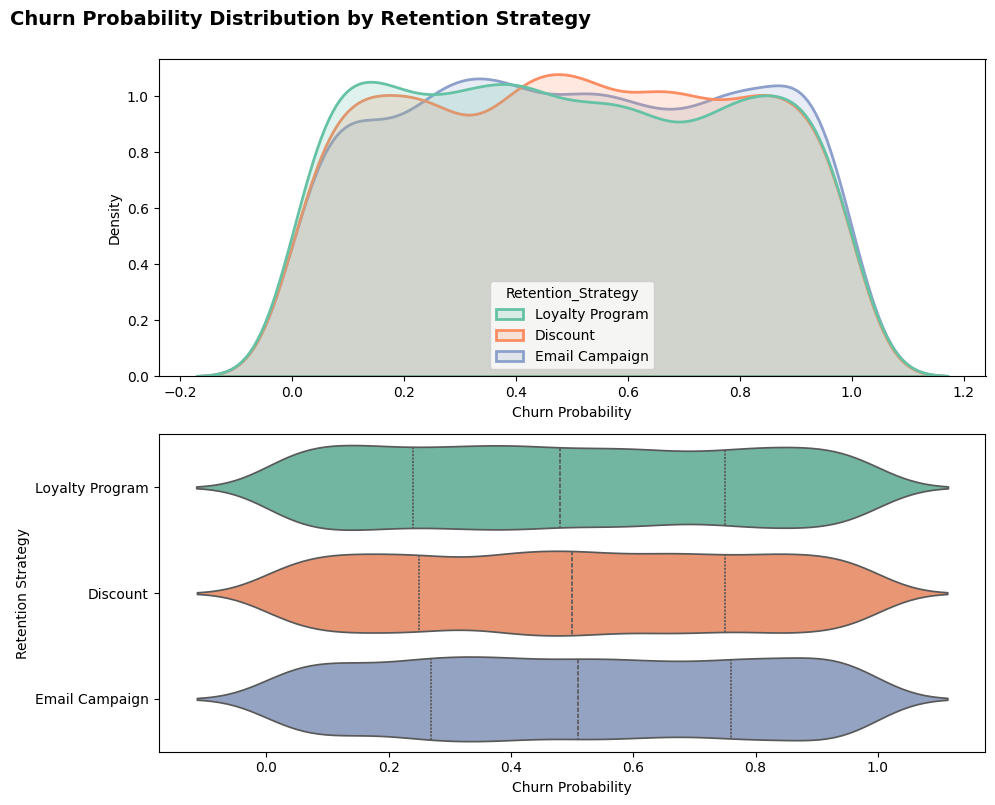

In [27]:
# KDE and violin plots for churn probability by retention strategy
fig, axes = plt.subplots(2,1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales, x = "Churn_Probability", hue = "Retention_Strategy", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0],)
axes[0].set_xlabel("Churn Probability")

# Violin plot
sns.violinplot(data=df_sales, x = "Churn_Probability", y = "Retention_Strategy", hue = "Retention_Strategy", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Retention Strategy")

fig.suptitle("Churn Probability Distribution by Retention Strategy", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that churn probability is spread widely across all three retention strategies. The distributions for Loyalty Program, Discount, and Email Campaign overlap heavily.

The violin plots also show similar spread and quartile positions across the three groups. This suggests that no retention strategy group has a clearly different churn probability distribution in this dataset.

Overall, Retention_Strategy does not strongly separate customers by churn probability. This is also consistent with the earlier observation that Dataset 2 has many evenly distributed variables.

##### **2.7.2 Lifetime Value by Region**

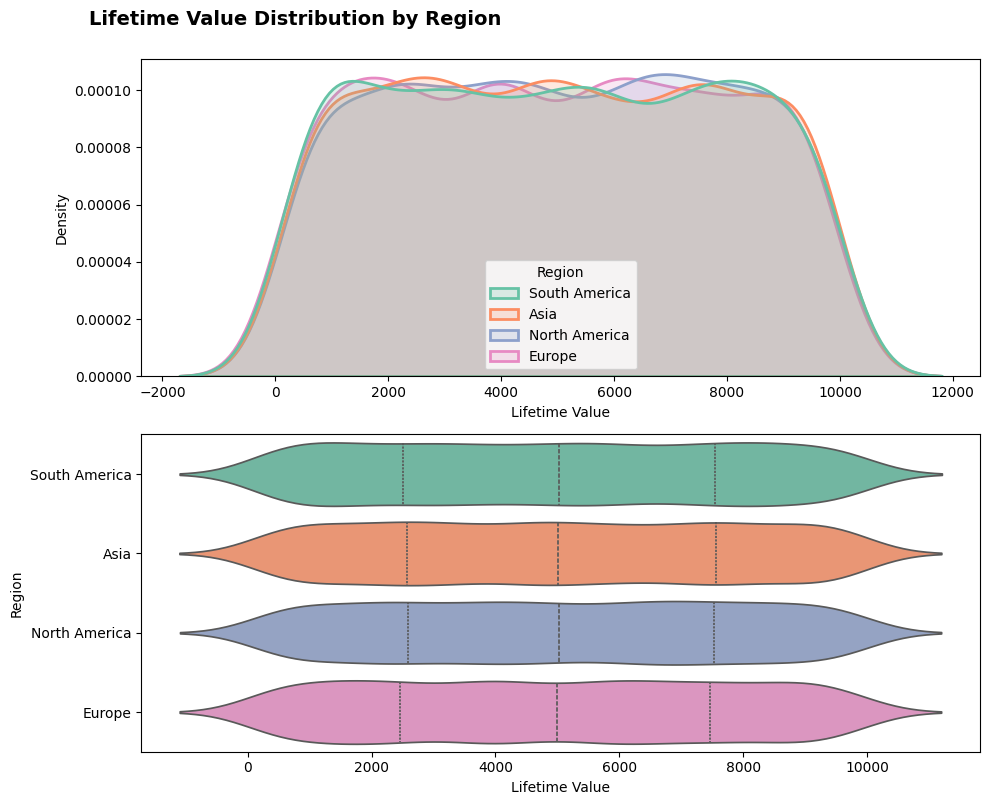

In [28]:
# KDE and violin plots for Lifetime Value by Region
fig, axes = plt.subplots(2,1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales, x="Lifetime_Value", hue="Region", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Lifetime Value")

# Violin plot
sns.violinplot(data=df_sales, x="Lifetime_Value", y="Region", hue="Region", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Lifetime Value")
axes[1].set_ylabel("Region")

fig.suptitle("Lifetime Value Distribution by Region", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that Lifetime_Value has a very similar distribution across all regions. South America, Asia, North America, and Europe all cover almost the full range of customer lifetime value.

The distributions overlap heavily, and the quartile lines in the violin plots are close across regions. This suggests that Region does not strongly separate customers by Lifetime_Value in this dataset.

Overall, customer lifetime value appears fairly balanced across regions, which is consistent with the overall uniform pattern observed in Dataset 2.

##### **2.7.3 Average Order Value by Most Frequent Category**

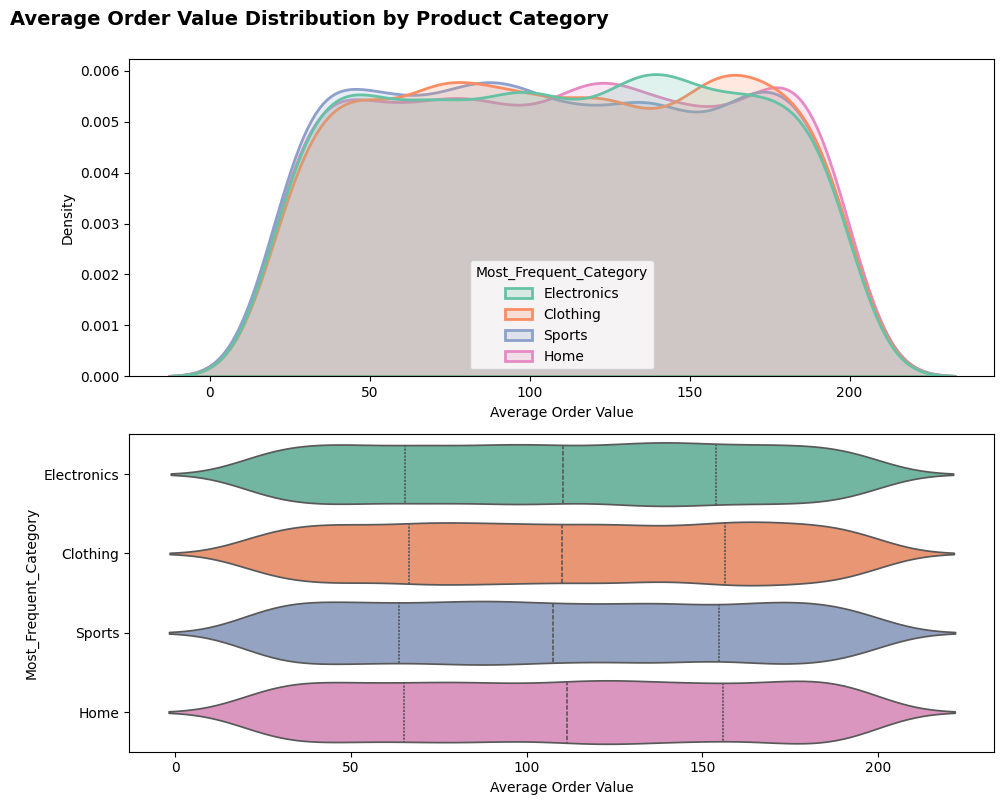

In [29]:
# KDE and violin plots for average order value by most frequent category
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales,x="Average_Order_Value",hue="Most_Frequent_Category",common_norm=False,fill=True,alpha=0.2,linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Average Order Value")

# Violin plot
sns.violinplot(data=df_sales, x="Average_Order_Value", y="Most_Frequent_Category", hue="Most_Frequent_Category", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Average Order Value")

fig.suptitle("Average Order Value Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that Average_Order_Value has a very similar distribution across the main product categories. Electronics, Clothing, Sports, and Home all cover almost the full range of average order values.

The distributions overlap heavily, and the quartile lines in the violin plots are close across categories. This suggests that Most_Frequent_Category does not strongly separate customers by Average_Order_Value in this dataset.

Overall, average order value appears fairly balanced across product categories. This is consistent with the earlier histogram and bar plot results, where many variables appeared evenly distributed.

#### **2.8 Final Week 4 Conclusion for Dataset 2**

The Week 4 analysis shows that Dataset 2 has very balanced and evenly distributed variables.

- The numeric variables do not appear normally distributed. Average_Order_Value, Time_Between_Purchases, Churn_Probability, and Lifetime_Value are spread fairly evenly across their ranges, creating mostly uniform-looking distributions rather than normal or strongly skewed shapes.

- Purchase_Frequency is a discrete numeric variable, so a count plot was more useful than a regular histogram. The values from 1 to 19 are fairly balanced, with no single purchase frequency dominating the dataset.

- Average_Order_Value ranges from about 20 to 200, Time_Between_Purchases ranges from about 5 to 89 days, Churn_Probability ranges from 0 to 1, and Lifetime_Value ranges from about 100 to 10,000. These ranges are reasonable, and the distributions do not show strong concentration around one specific value.

- The boxplots did not show obvious outliers. The numeric variables stay within their expected ranges, and no extreme values appear to be data errors.

- The categorical variables are also very balanced. Product category, region, season, preferred purchase time, and retention strategy all have relatively similar category counts.

- The grouped distribution plots showed heavy overlap between groups. Churn_Probability looked very similar across retention strategies, Lifetime_Value looked very similar across regions, and Average_Order_Value looked very similar across product categories. This suggests that the selected categorical variables do not strongly separate the numeric variables in this dataset.

- Compared with Dataset 1, Dataset 2 looks much more uniform and less naturally varied. This suggests that the dataset may be synthetic or generated for practice, so business conclusions should be written carefully.

Overall, Dataset 2 is clean and usable for visualization and distribution analysis, but the patterns are very even and the grouped comparisons do not show strong separation between categories.

### **Dataset 3: E-commerce Customer Churn Analysis and Prediction**

- This dataset is customer-based. Each row represents one unique customer and includes information about customer behavior, satisfaction, complaints, order activity, and churn status.

- It contains variables such as tenure, preferred login device, city tier, warehouse-to-home distance, time spent on the app, order count, coupon usage, satisfaction score, complaint status, cashback amount, and churn.

- In this section, I use the EDA version of the dataset, `df_churn_eda`, to explore important numeric and categorical variables related to customer behavior, satisfaction, engagement, order activity, and churn risk. 


#### **Dataset 3 Column Descriptions**  


- `CustomerID`: Unique ID for each customer.

- `Churn`: Target variable showing whether the customer churned; 1 means churned, 0 means not churned.

- `Tenure`: How long the customer has been with the company, likely in months.

- `PreferredLoginDevice`: The device the customer usually uses to log in, such as mobile phone or computer.

- `CityTier`: The tier/category of the customer’s city, usually from 1 to 3.

- `WarehouseToHome`: Distance between the warehouse and the customer’s home, likely in kilometers.

- `PreferredPaymentMode`: The customer’s preferred payment method.

- `Gender`: Customer gender.

- `HourSpendOnApp`: Number of hours the customer spends on the app.

- `NumberOfDeviceRegistered`: Number of devices registered by the customer.

- `PreferedOrderCat`: The customer’s preferred order/product category.

- `SatisfactionScore`: Customer satisfaction score, from 1 to 5.

- `MaritalStatus`: Customer marital status.

- `NumberOfAddress`: Number of addresses saved by the customer.

- `Complain`: Whether the customer complained; 1 means yes, 0 means no.

- `OrderAmountHikeFromlastYear`: Increase in order amount compared with last year, likely as a percentage.

- `CouponUsed`: Number of coupons used by the customer.

- `OrderCount`: Number of orders placed by the customer.

- `DaySinceLastOrder`: Number of days since the customer’s last order.

- `CashbackAmount`: Cashback amount received by the customer.

#### **3.1 load and check**

In [30]:
# Load the cleaned dataset from the previous cleaning step
df_churn = pd.read_pickle("data/df_churn_eda.pkl")

# Quick check
df_churn.shape

(5630, 20)

In [31]:
df_churn.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [32]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

#### **3.2 Selecting Columns for Distribution Analysis**

In this step, I will choose the columns that are useful for Week 4 distribution analysis.

I will not use identifier columns as main plot variables.

I will separate the columns into numeric variables, discrete numeric variables, categorical variables, and possible grouped analysis variables.

In [33]:
numeric_cols_churn = ["Tenure","WarehouseToHome","OrderAmountHikeFromlastYear","CashbackAmount","HourSpendOnApp","CouponUsed","OrderCount","DaySinceLastOrder"]
discrete_numeric_cols_churn = ["CityTier","NumberOfDeviceRegistered","SatisfactionScore","NumberOfAddress","Complain","Churn"]
categorical_cols_churn = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]
identifier_cols_churn = ["CustomerID"]

print("Numeric columns:")
print(numeric_cols_churn)

print("\nDiscrete numeric columns:")
print(discrete_numeric_cols_churn)

print("\nCategorical columns:")
print(categorical_cols_churn)

print("\nIdentifier columns:")
print(identifier_cols_churn)

Numeric columns:
['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear', 'CashbackAmount', 'HourSpendOnApp', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

Discrete numeric columns:
['CityTier', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'Churn']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Identifier columns:
['CustomerID']


#### **3.3 Summary Statistics for Selected Numeric Variables**

In this step, I will create a summary table for the selected numeric and discrete numeric variables.

This table will help me understand the center, range, and spread of the main numeric variables before drawing histograms and boxplots.

In [34]:
summary_cols_churn = numeric_cols_churn + discrete_numeric_cols_churn
summary_stats_churn = df_churn[summary_cols_churn].agg(["mean", "median", lambda x:x.mode().iloc[0], "min", "max"]).T
summary_stats_churn = summary_stats_churn.rename(columns={"<lambda>": "mode"})
summary_stats_churn

,mean,median,mode,min,max
Tenure,10.189899,9.00,1.00,0.0,61.00
WarehouseToHome,15.639896,14.00,9.00,5.0,127.00
OrderAmountHikeFromlastYear,15.707922,15.00,14.00,11.0,26.00
CashbackAmount,177.223030,163.28,123.42,0.0,324.99
HourSpendOnApp,2.931535,3.00,3.00,0.0,5.00
CouponUsed,1.751023,1.00,1.00,0.0,16.00
OrderCount,3.008004,2.00,2.00,1.0,16.00
DaySinceLastOrder,4.543491,3.00,3.00,0.0,46.00
CityTier,1.654707,1.00,1.00,1.0,3.00
NumberOfDeviceRegistered,3.688988,4.00,4.00,1.0,6.00


The summary table shows that the selected variables have different ranges and centers.

`Tenure` ranges from 0 to 61, with a mean of about 10.19 and a median of 9. This suggests that many customers have shorter or medium tenure, but some customers have much longer tenure.

`WarehouseToHome` ranges from 5 to 127. The median is 14, while the maximum is much higher, so this variable may have some high-end values.

`OrderAmountHikeFromlastYear` has a smaller range from 11 to 26. Its mean and median are close, so the values are mostly centered around 15 to 16.

`CashbackAmount` ranges from 0 to 324.99. The mean is higher than the median, which suggests some right-skew.

The count-based variables, such as `CouponUsed`, `OrderCount`, and `DaySinceLastOrder`, have means higher than their medians. This suggests that most customers have lower values, while some customers have higher counts.

`Complain` and `Churn` are binary variables. The mean of `Complain` shows that about 28.5% of customers complained. The mean of `Churn` shows that about 16.8% of customers churned.

#### **3.4 Distribution Plots for Numeric Variables**

In this step, I will use histograms for the selected numeric variables.

Other variables are more count-based, so I will still use count plots.

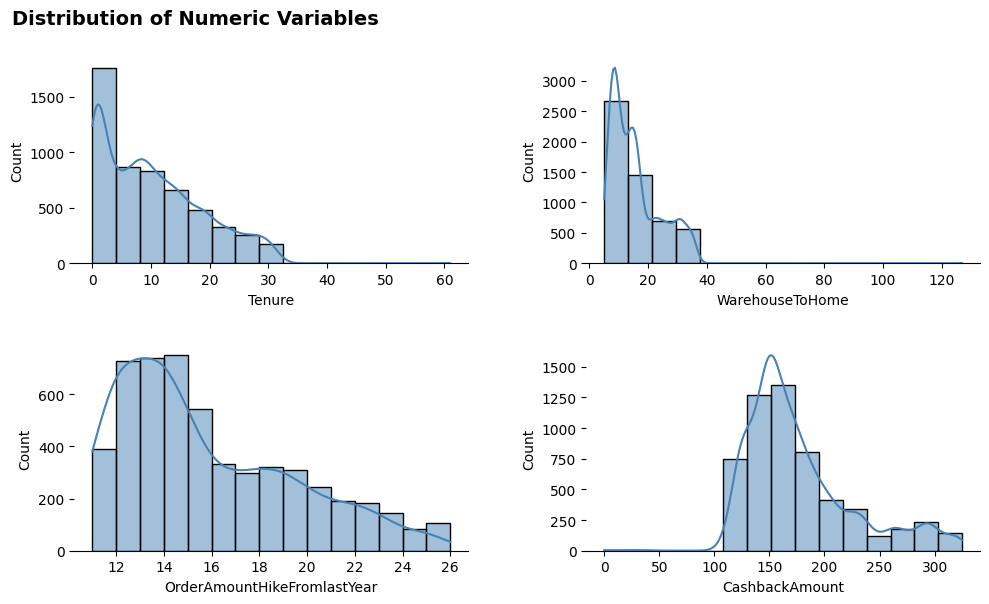

In [35]:
# histograms for numeric variables in churn dataset
bin_settings = {"Tenure": 15, "WarehouseToHome": 15, "OrderAmountHikeFromlastYear": 15, "CashbackAmount": 15}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_churn, x=col, bins=bin_settings[col], kde= True, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

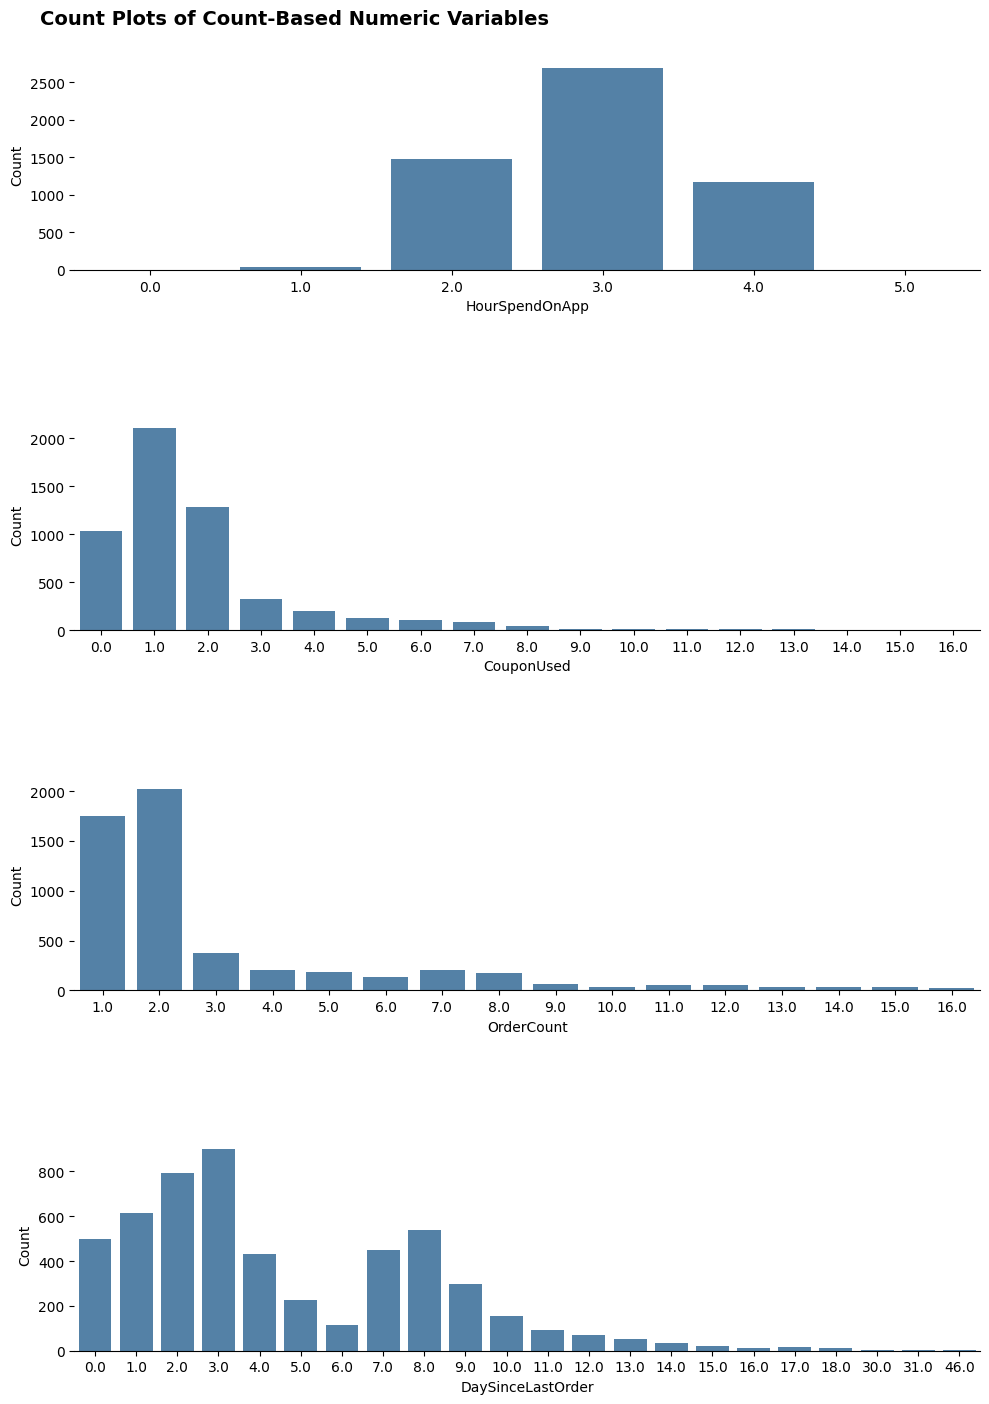

In [36]:
# Countplots for count-based numeric variables
plot_cols = ["HourSpendOnApp", "CouponUsed", "OrderCount", "DaySinceLastOrder"]
fig, axes = plt.subplots(4,1, figsize=(10,14))

for i, col in enumerate(plot_cols):
    sns.countplot(data=df_churn, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

fig.suptitle("Count Plots of Count-Based Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.subplots_adjust(hspace=0.7)
plt.show()

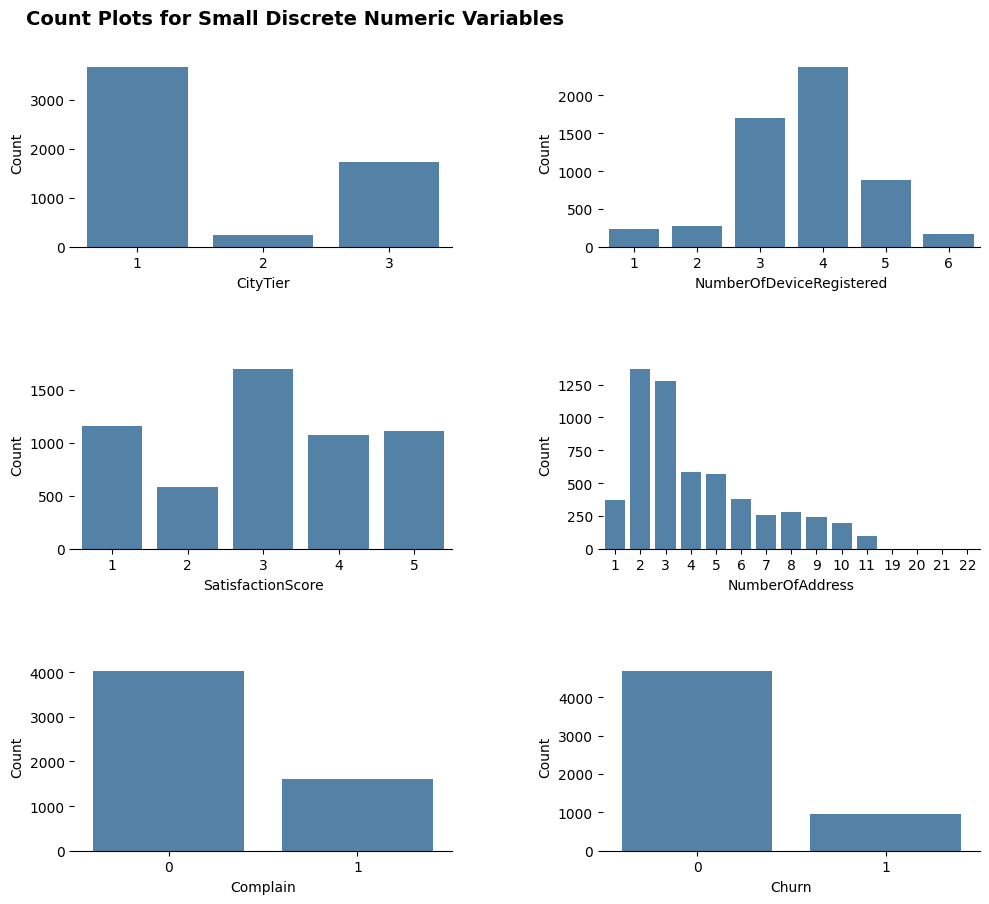

In [37]:
# Count plots for small discrete numeric variables
cols = 2
plot_cols = discrete_numeric_cols_churn 
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.countplot(data=df_churn, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Count Plots for Small Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace = 0.4, hspace=0.6)
plt.show()

The distribution plots show that the numeric variables have different distribution shapes. Most of them do not look normally distributed.

`Tenure` is right-skewed. Most customers have lower tenure values, while fewer customers have very long tenure. The range goes from 0 to 61.

`WarehouseToHome` is also right-skewed. Most customers are closer to the warehouse, but there are a few much higher values. The maximum value is 127, which may appear as a high-end outlier, but it is not automatically invalid.

`OrderAmountHikeFromlastYear` is not normally distributed. It is more concentrated in the lower-to-middle range, especially around 12 to 15, and then gradually decreases toward higher values. The range is from 11 to 26.

`CashbackAmount` is right-skewed. Most values are around the middle range, roughly between 120 and 200, but there are also higher cashback amounts up to 324.99.

For the count-based numeric variables, the distributions are discrete rather than continuous.

`HourSpendOnApp` is concentrated around 2 to 4 hours, especially around 3 hours.

`CouponUsed` is right-skewed. Most customers used only a small number of coupons, while a few customers used many more.

`OrderCount` is also right-skewed. Most customers placed only a small number of orders, especially around 1 or 2, while fewer customers placed many orders.

`DaySinceLastOrder` is right-skewed as well. Most customers have lower values, but a few customers have much longer gaps since their last order.

The small discrete numeric variables also show uneven distributions. `CityTier` is dominated by tiers 1 and 3, while tier 2 has fewer customers.  

`NumberOfDeviceRegistered` is concentrated around 3 and 4 devices.  

`SatisfactionScore` is highest at 3, but all scores from 1 to 5 are present.

The binary variables are imbalanced. Most customers did not complain, and most customers did not churn. This confirms that `Churn` is an imbalanced target variable.

#### **3.5 Boxplots and Outlier Check**

In this step, I will use boxplots to check the spread of selected numeric variables and identify possible outliers.

I will not remove outliers automatically. I will only use the boxplots to understand whether some values are unusually high or still reasonable for this dataset.

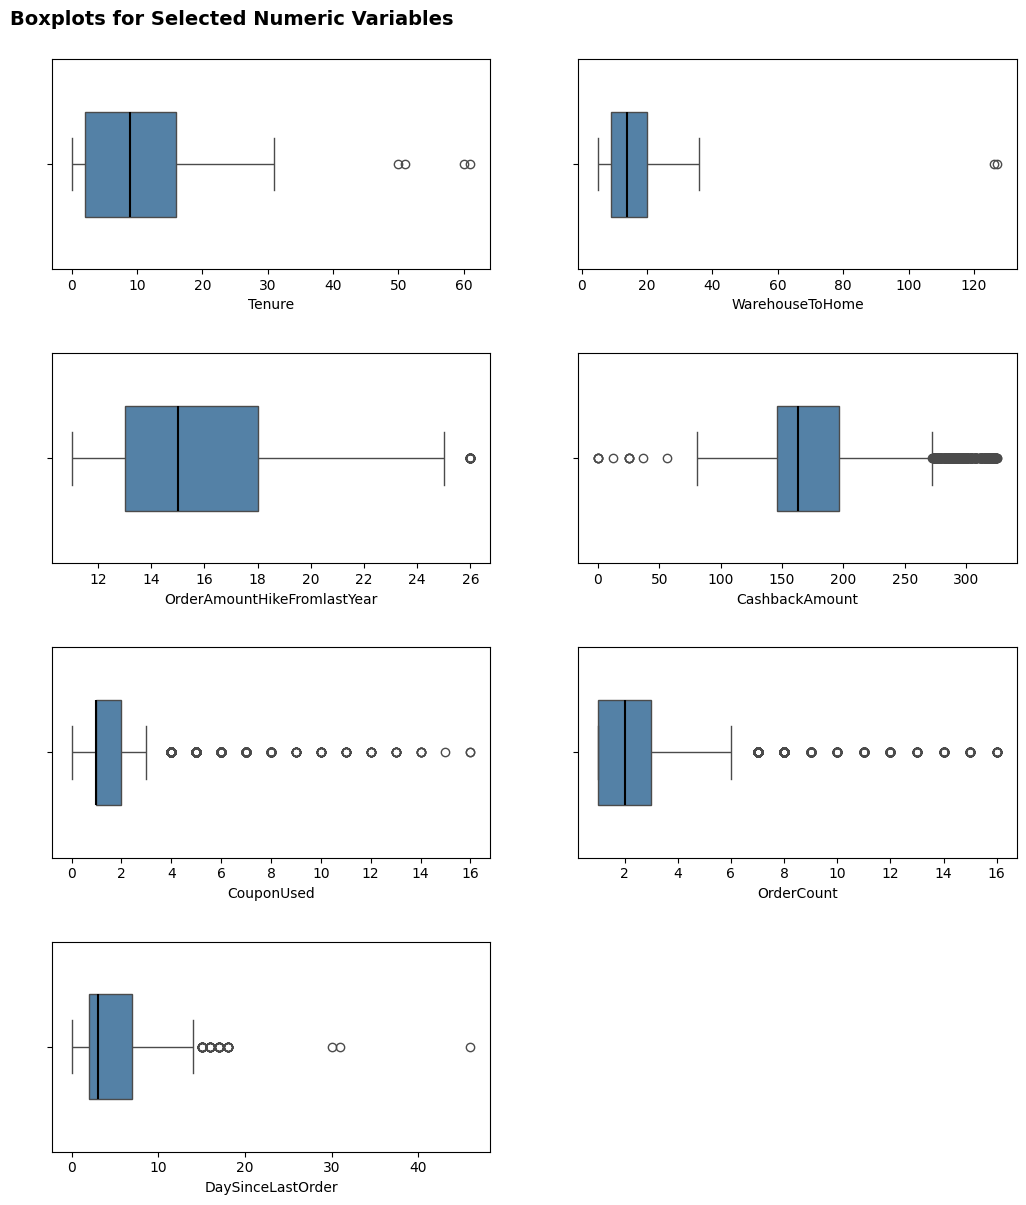

In [38]:
boxplot_cols_churn = ["Tenure","WarehouseToHome","OrderAmountHikeFromlastYear","CashbackAmount","CouponUsed","OrderCount","DaySinceLastOrder"]

cols = 2
rows = (len(boxplot_cols_churn) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_churn):
    sns.boxplot(data=df_churn, x=col, ax=axes[i], color="steelblue", width=0.5, medianprops={"color": "black", "linewidth": 1.5})
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots for Selected Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

The boxplots show that several numeric variables have visible high-end values.

`Tenure` has a few high values around 50 to 61. These look like long-term customers rather than impossible values.

`WarehouseToHome` has a very high value around 127. This appears as an outlier compared with most customers, but it is not automatically invalid because some customers may live far from the warehouse.

`OrderAmountHikeFromlastYear` has a small number of high-end values near 26, but the range still looks reasonable.

`CashbackAmount` has both very low and high values. Most customers are around the middle range, but some customers receive much higher cashback amounts.

`CouponUsed`, `OrderCount`, and `DaySinceLastOrder` show many high-end points. This matches the right-skewed patterns seen in the distribution plots.

No outliers were removed in this step. These values may represent real customer behavior, so they should be kept unless there is clear evidence that they are invalid.

#### **3.6 Bar Plots for Categorical Variables**

In this step, I will use bar plots to check the distribution of the categorical variables.

The goal is to see which categories are more common and whether any category is strongly dominant.

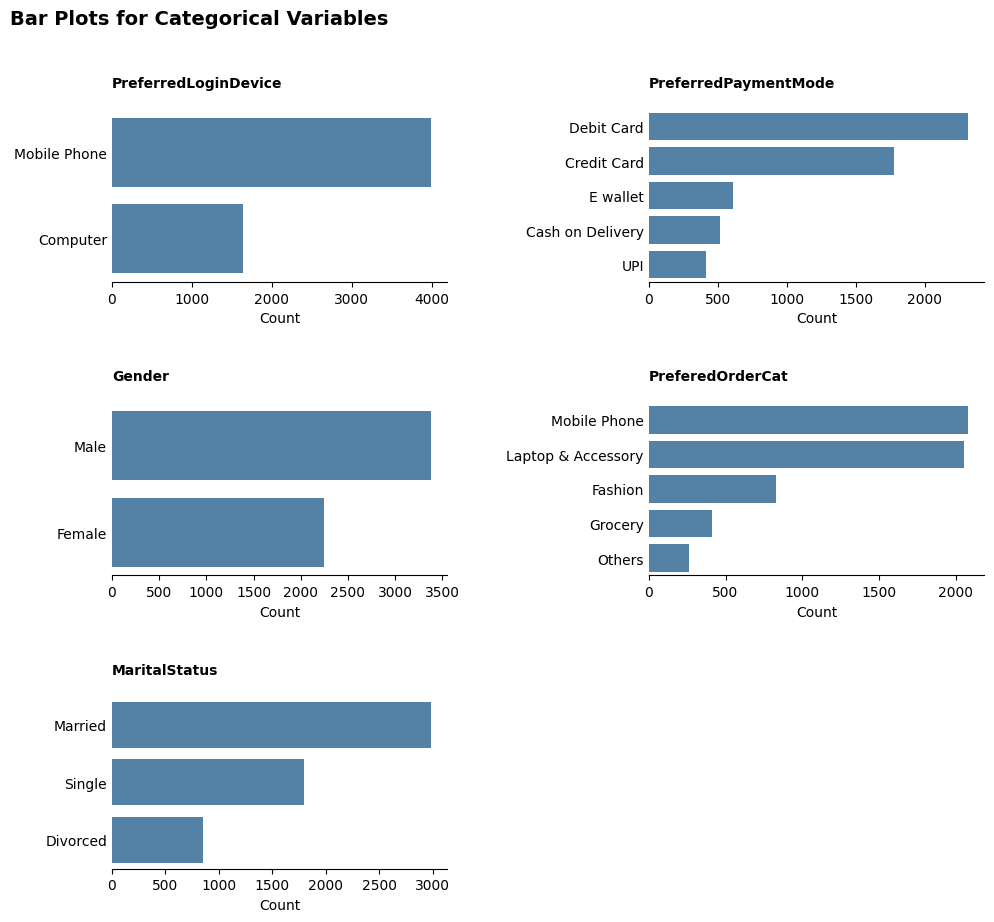

In [39]:
# Bar plots for categorical variables
cols = 2
plot_cols = categorical_cols_churn
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    order = df_churn[col].value_counts().index
    sns.countplot(data=df_churn, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=16, fontsize=10, fontweight="bold")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Bar Plots for Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.6, hspace=0.7)
plt.show()

The categorical bar plots show that some categories are clearly more common than others.

Most customers use `Mobile Phone` as their preferred login device, while fewer customers use `Computer`.

For payment method, `Debit Card` and `Credit Card` are the most common options. `UPI`, `Cash on Delivery`, and `E wallet` have smaller counts.

The gender distribution is not fully balanced. There are more male customers than female customers.

For preferred order category, `Mobile Phone` and `Laptop & Accessory` are the two largest categories. `Fashion`, `Grocery`, and `Others` have lower counts.

For marital status, `Married` is the largest group, followed by `Single` and then `Divorced`.

Overall, the categorical variables are not perfectly balanced. Some customer groups and preferences are clearly more common than others.

#### **3.7 Grouped Distribution Analysis**

In this step, I will compare selected variables across churn groups.

The goal is to see whether churned and non-churned customers have different behavior patterns.

Because `Churn` is the main target variable in this dataset, I will use it as the main grouping variable.

##### **3.7.1 Tenure Distribution by Churn**

In this plot, I will compare the `Tenure` distribution for customers who churned and customers who did not churn.

The goal is to see whether churned customers tend to have shorter or longer tenure.

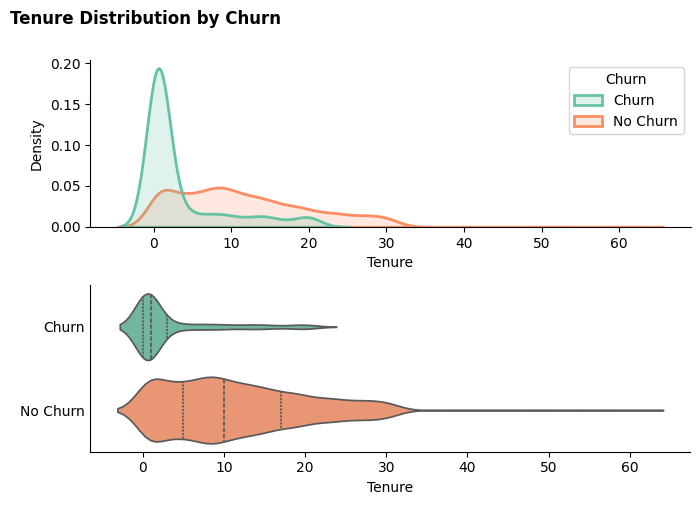

In [40]:
# KDE and violin plots for churn probability by tenure
churn_labels = df_churn["Churn"].map({0: "No Churn", 1: "Churn"})

fig, axes = plt.subplots(2,1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn, x = "Tenure", hue = churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Tenure")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn, x = "Tenure", y = churn_labels, hue = churn_labels, inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Tenure")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Tenure Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.show()

The KDE and violin plots show a clear difference in `Tenure` between churned and non-churned customers.

Customers who churned are strongly concentrated at very low tenure values. This means many churned customers seem to be newer customers.

Customers who did not churn have a wider tenure distribution and include more customers with medium and long tenure.

The two groups overlap at lower tenure values, but the non-churn group extends much farther to the right.

This suggests that `Tenure` is an important variable for churn analysis.

##### **3.7.2 Day Since Last Order Distribution by Churn**

In this plot, I will compare `DaySinceLastOrder` between churned and non-churned customers.

The goal is to see whether customers who churned tend to have a longer time since their last order.

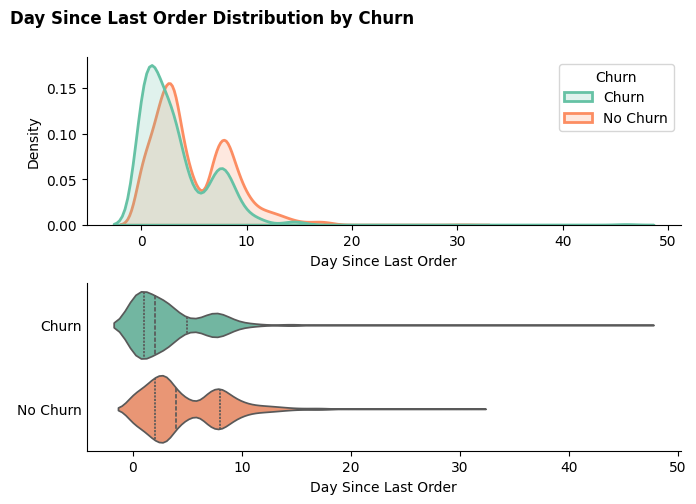

In [41]:
fig, axes = plt.subplots(2,1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data= df_churn, x = "DaySinceLastOrder", hue = churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Day Since Last Order")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn, x = "DaySinceLastOrder", y = churn_labels, hue = churn_labels, inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Day Since Last Order")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Day Since Last Order Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that `DaySinceLastOrder` is right-skewed for both churned and non-churned customers.

Both groups show a two-peak pattern. The first and larger peak appears around 1 to 3 days since the last order.

A smaller second peak appears around 7 to 8 days, especially for the non-churn group.

The two groups overlap a lot, so `DaySinceLastOrder` does not clearly separate churned and non-churned customers by itself.

The two-peak pattern may suggest different order recency behaviors. One group appears to have very recent orders, while another smaller group may follow a longer or more weekly purchase cycle.

This is only an interpretation from the distribution shape, so it should be explored more later before making a strong business conclusion.

Because `DaySinceLastOrder` is a count-based variable, the KDE curve is used only to compare the general shape of the two groups.

##### **3.7.3 Cashback Amount Distribution by Churn**

In this plot, I will compare `CashbackAmount` between churned and non-churned customers.

The goal is to see whether cashback amount looks different across churn groups.

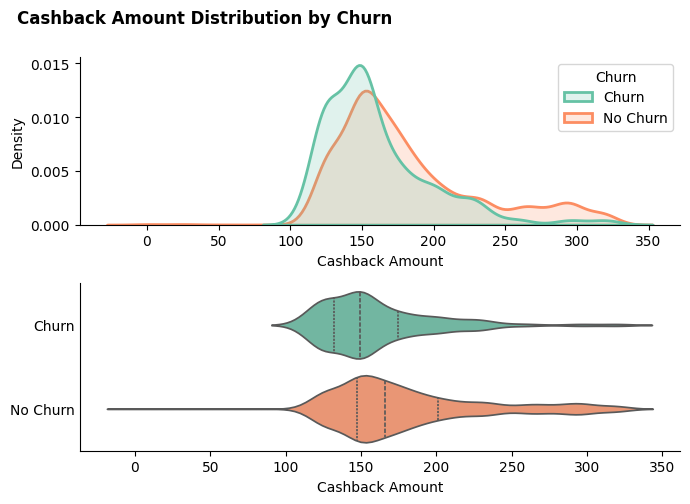

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn,x="CashbackAmount",hue=churn_labels,common_norm=False,fill=True,alpha=0.2,linewidth=2,palette="Set2",ax=axes[0])
axes[0].set_xlabel("Cashback Amount")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn,x="CashbackAmount",y=churn_labels,hue=churn_labels,inner="quartile",palette="Set2",ax=axes[1])
axes[1].set_xlabel("Cashback Amount")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Cashback Amount Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that `CashbackAmount` has different patterns for churned and non-churned customers.

Both groups are mostly concentrated around the middle cashback range, especially around 130 to 180.

The churn group does not appear much in the very low cashback range. It is more concentrated around roughly 120 to 170, with a peak close to 150.

The non-churn group has a similar main range, but it is more spread out. It extends more clearly toward higher cashback amounts, especially above 220 and up to around 320.

Both groups overlap strongly in the middle range, so `CashbackAmount` does not completely separate churned and non-churned customers.

However, the higher cashback tail is more visible for the non-churn group, while the churn group is more concentrated in a narrower middle range.

##### **3.7.4 Warehouse to Home Distribution by Churn**

In this plot, I will compare `WarehouseToHome` between churned and non-churned customers.

The goal is to see whether customers who churned tend to live farther from the warehouse compared with customers who did not churn.

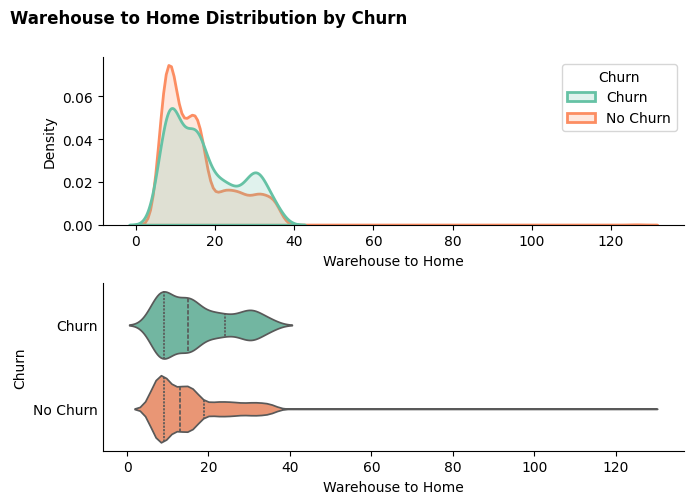

In [43]:
# KDE and violin plots for WarehouseToHome by churn
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn, x="WarehouseToHome", hue=churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Warehouse to Home")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_churn, x="WarehouseToHome", y=churn_labels, hue=churn_labels, inner="quartile", palette="Set2", ax=axes[1])
axes[1].set_xlabel("Warehouse to Home")
axes[1].set_ylabel("Churn")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
fig.suptitle("Warehouse to Home Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The KDE and violin plots show that `WarehouseToHome` has different patterns for churned and non-churned customers.

Both groups are right-skewed and most customers are in the lower distance range.

The non-churn group is more concentrated around lower values, especially around 5 to 15.

The churn group is more spread out and has more density in the higher range, especially around 20 to 35.

The two groups still overlap, especially in the lower distance range, so `WarehouseToHome` does not perfectly separate churned and non-churned customers.

However, the plot suggests that customers who churned may be more common at higher warehouse-to-home distances.

This could be useful for later churn analysis because distance may be related to delivery experience or service convenience.

##### **3.7.5 Churn Rate by Satisfaction Score**

In this plot, I will calculate the churn rate for each satisfaction score.

The churn rate shows the percentage of customers who churned within each satisfaction score group.

This is more useful than raw counts because the number of customers is not the same for every satisfaction score.

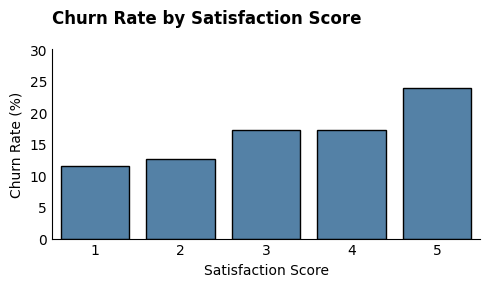

In [44]:
# Calculate churn rate percentage by SatisfactionScore
satisfaction_churn_rate = (df_churn.groupby("SatisfactionScore")["Churn"].mean().reset_index())

satisfaction_churn_rate["Churn_Percent"] = satisfaction_churn_rate["Churn"] * 100

# Bar plot for churn rate by Satisfaction Score
plt.figure(figsize=(5, 3))
ax = sns.barplot(data=satisfaction_churn_rate,x="SatisfactionScore",y="Churn_Percent",color="steelblue", edgecolor="black")

ax.set_title("Churn Rate by Satisfaction Score", loc="left", fontsize=12, pad=12,fontweight="bold", y=1.05, x=0)
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 30)
axes = plt.gca()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

The churn rate plot shows that churn rate changes across satisfaction scores.

Customers with satisfaction scores 1 and 2 have lower churn rates, around 11% to 13%.

The churn rate increases for scores 3 and 4, reaching about 17%.

Score 5 has the highest churn rate, around 24%.

This pattern is interesting because higher satisfaction scores do not show lower churn in this dataset.

This suggests that `SatisfactionScore` alone does not explain churn in a simple way, and it should be explored with other variables before making a strong conclusion.

#### **3.8 Final Week 4 Conclusion for Dataset 3**

The Week 4 distribution analysis shows that Dataset 3 is useful for understanding customer churn behavior.

- The numeric variables do not all follow normal distributions. Several variables, such as `Tenure`, `WarehouseToHome`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder`, are right-skewed.  
This means most customers have lower values, while a smaller number of customers have much higher values.

- `OrderAmountHikeFromlastYear` is more concentrated in the lower-to-middle range, mostly around 12 to 20. `CashbackAmount` is also concentrated around the middle range, but it has a right tail with some higher cashback values.

- Some numeric variables behave more like count-based or discrete variables. For example, `HourSpendOnApp`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder` have repeated whole-number values.  
Other variables such as `CityTier`, `SatisfactionScore`, `Complain`, and `Churn` are also discrete, so count-style plots were more useful for them.

- The boxplots showed several high-end values, especially in `WarehouseToHome`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder`. These values may look like outliers, but they were not removed because they can still represent real customer behavior.

- The categorical variables are not perfectly balanced. Most customers use `Mobile Phone` as their preferred login device. `Debit Card` and `Credit Card` are the most common payment methods. `Mobile Phone` and `Laptop & Accessory` are the largest preferred order categories. The marital status distribution is also uneven, with `Married` being the largest group.

- The target variable `Churn` is imbalanced. Most customers did not churn, while churned customers are the smaller group. This is important to remember for future modeling because accuracy alone may not be a good evaluation metric.

- The grouped distribution analysis showed some useful churn-related patterns. `Tenure` showed the clearest difference: churned customers were strongly concentrated at low tenure values, while non-churned customers had a wider tenure range.

- `DaySinceLastOrder` showed a right-skewed and two-peak pattern for both churn groups. The two groups overlapped a lot, so this variable does not clearly separate churned and non-churned customers by itself.

- `CashbackAmount` showed overlap between churned and non-churned customers. Both groups were mostly concentrated in the middle cashback range, but the non-churn group extended more into higher cashback amounts.

- `WarehouseToHome` showed a more noticeable difference. Churned customers appeared more spread out and had more density at higher warehouse-to-home distances, while non-churned customers were more concentrated at lower distances.

- `SatisfactionScore` had an interesting pattern. The churn rate was highest for satisfaction score 5, which means higher satisfaction scores did not simply mean lower churn in this dataset. This should be explored more later before making a strong business conclusion.

Overall, Dataset 3 is usable for future analysis. The most important variables to remember are `Tenure`, `WarehouseToHome`, `DaySinceLastOrder`, `CashbackAmount`, `SatisfactionScore`, and `Churn`.

### **Dataset 4: E-Commerce Customer Behavior and Sales Analysis - TR**

This dataset contains purchase experience, customer behavior, and sales information.

It includes order details, customer demographics, product category, payment method, device type, session activity, delivery time, customer rating, and returning customer status.

In this section, I use the cleaned EDA version of the dataset to explore important numeric and categorical variables related to purchase behavior, customer experience, sales amount, delivery, and customer satisfaction.


#### **Dataset 4 Column Descriptions**

- `Order_ID`: Unique identifier for each order.

- `Customer_ID`: Unique identifier for each customer.

- `Date`: Date of the purchase or transaction.

- `Age`: Customer age.

- `Gender`: Customer gender.

- `City`: Customer city.

- `Product_Category`: Category of the purchased product.

- `Unit_Price`: Price of one unit of the product.

- `Quantity`: Number of units purchased.

- `Discount_Amount`: Discount amount applied to the purchase.

- `Total_Amount`: Final total amount of the purchase.

- `Payment_Method`: Payment method used by the customer.

- `Device_Type`: Device type used during the purchase.

- `Session_Duration_Minutes`: Length of the customer’s shopping session in minutes.

- `Pages_Viewed`: Number of pages viewed during the session.

- `Delivery_Time_Days`: Number of days it took to deliver the order.

- `Customer_Rating`: Customer rating for the purchase experience, from 1 to 5.

- `Is_Returning_Customer`: Shows whether the customer is a returning customer or a new customer.

#### **4.1 load and check**

In [45]:
# Load the cleaned dataset from the previous cleaning step
df_purchase_experience = pd.read_pickle("data/df_purchase_experience_eda.pkl")

# Quick check
df_purchase_experience.shape

(5000, 18)

In [46]:
df_purchase_experience.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [47]:
df_purchase_experience.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

#### **4.2 Selecting Columns for Distribution Analysis**

In this step, we choose the columns that are useful for Week 4 distribution analysis. We separate continuous numeric variables, discrete numeric variables, categorical variables, identifier columns, and possible grouping variables.

In [48]:
continuous_numeric_cols_purchase = ["Age","Unit_Price","Discount_Amount","Total_Amount","Session_Duration_Minutes","Delivery_Time_Days"]
discrete_numeric_cols_purchase = ["Quantity","Pages_Viewed","Customer_Rating"]
categorical_cols_purchase = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]
identifier_cols_purchase = ["Order_ID","Customer_ID"]

print("Continuous numeric columns:")
print(continuous_numeric_cols_purchase)

print("\nDiscrete numeric columns:")
print(discrete_numeric_cols_purchase)

print("\nCategorical columns:")
print(categorical_cols_purchase)

print("\nIdentifier columns:")
print(identifier_cols_purchase)

Continuous numeric columns:
['Age', 'Unit_Price', 'Discount_Amount', 'Total_Amount', 'Session_Duration_Minutes', 'Delivery_Time_Days']

Discrete numeric columns:
['Quantity', 'Pages_Viewed', 'Customer_Rating']

Categorical columns:
['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type', 'Is_Returning_Customer']

Identifier columns:
['Order_ID', 'Customer_ID']


#### **4.3 Summary Statistics for Selected Numeric Variables**

In this step, we calculate mean, median, mode, minimum, and maximum for the selected numeric variables. This helps us understand the center and range of each variable before drawing distribution plots.

We use both continuous and discrete numeric variables here because this summary table gives a quick overview of all important numeric columns.

In [49]:
summary_cols_purchase = continuous_numeric_cols_purchase + discrete_numeric_cols_purchase
summary_stats_purchase = df_purchase_experience[summary_cols_purchase].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T.rename(columns={"<lambda>": "mode"})
summary_stats_purchase

,mean,median,mode,min,max
Age,35.032600,35.00,18.00,18.00,75.00
Unit_Price,455.834120,182.95,30.10,5.18,7159.45
Discount_Amount,24.852804,0.00,0.00,0.00,1525.55
Total_Amount,983.108914,337.91,23.05,7.87,22023.90
Session_Duration_Minutes,14.573400,13.00,9.00,1.00,73.00
Delivery_Time_Days,6.497000,6.00,5.00,1.00,25.00
Quantity,2.220000,2.00,1.00,1.00,5.00
Pages_Viewed,8.984200,9.00,8.00,1.00,24.00
Customer_Rating,3.902800,4.00,5.00,1.00,5.00


The summary statistics show that the selected numeric variables have valid and reasonable ranges.

- `Age` ranges from 18 to 75, with a mean and median both around 35. This suggests that customer age is centered around the mid-30s.

- `Unit_Price` ranges from 5.18 to 7,159.45. The mean is about 455.83, while the median is 182.95. Since the mean is much higher than the median, `Unit_Price` is likely right-skewed.

- `Discount_Amount` ranges from 0 to 1,525.55. The median and mode are both 0, which means many transactions did not receive any discount. The higher mean suggests that some transactions had larger discounts.

- `Total_Amount` ranges from 7.87 to 22,023.90. The mean is about 983.11, while the median is 337.91. This large difference suggests that total order amount is also strongly right-skewed.

- `Session_Duration_Minutes` ranges from 1 to 73 minutes. The mean is about 14.57 and the median is 13, so most sessions appear to be relatively short, with some longer sessions.

- `Delivery_Time_Days` ranges from 1 to 25 days. The mean is about 6.50 and the median is 6, so most deliveries appear to take around one week.

- `Quantity` ranges from 1 to 5, with a median of 2 and a mode of 1. This is a discrete purchase-count variable, so a count-style plot may be more useful than a regular histogram.

- `Pages_Viewed` ranges from 1 to 24, with a mean and median close to 9. This variable is also count-based, but it has a wider range than `Quantity`.

- `Customer_Rating` ranges from 1 to 5, with a median of 4 and a mode of 5. This suggests that ratings are generally positive. Since this is a discrete rating variable, a count plot will be more appropriate than a continuous histogram.

#### **4.4 Histograms for Continuous Numeric Variables**

In this step, we draw histograms for the selected continuous numeric variables. These plots help us understand the distribution shape, including whether each variable looks normal, skewed, uniform, or unusual.

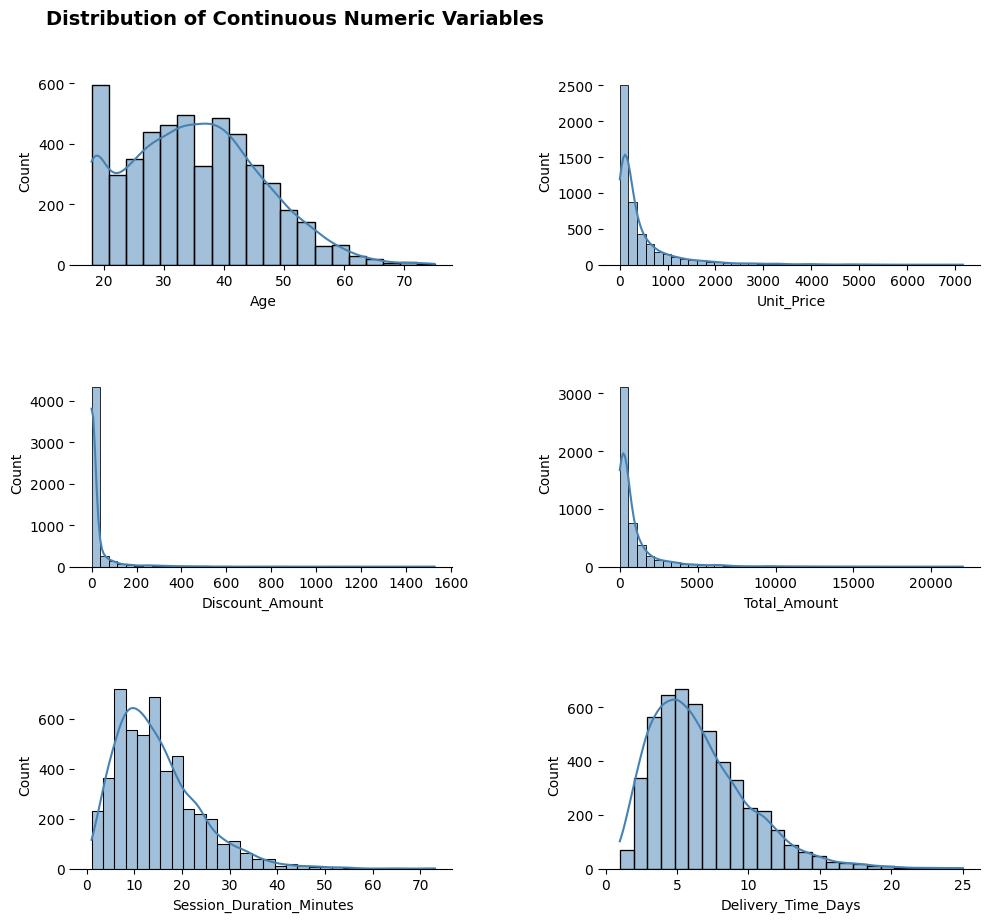

In [50]:
# Histograms for continuous numeric variables
bin_settings = {"Age": 20, "Unit_Price": 40, "Discount_Amount": 40, "Total_Amount": 40, "Session_Duration_Minutes": 30, "Delivery_Time_Days": 25}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_purchase_experience, x=col, bins=bin_settings[col], kde= True, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Continuous Numeric Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

The histograms show that the continuous numeric variables in Dataset 4 do not all follow normal distributions.

`Age` is concentrated mostly between the late teens and the mid-40s, with fewer customers at older ages. The distribution has a right tail up to 75, so it is slightly right-skewed rather than perfectly normal.

`Unit_Price` is strongly right-skewed. Most products have relatively low unit prices, but a small number of products have very high prices, reaching above 7,000. These high values look like possible high-end products rather than invalid values.

`Discount_Amount` is also strongly right-skewed. Most transactions have no discount or a very small discount, which matches the earlier summary table where the median and mode were both 0. A small number of transactions have much larger discount amounts.

`Total_Amount` is strongly right-skewed as well. Most orders are in the lower total amount range, but some orders have very large total amounts, reaching above 20,000. This is likely related to expensive products, larger quantities, or both.

`Session_Duration_Minutes` is right-skewed. Most sessions are under about 25 minutes, but a smaller number of sessions last much longer, up to around 73 minutes.

`Delivery_Time_Days` is also right-skewed. Most deliveries appear to take around 4 to 8 days, but some orders take longer, reaching up to 25 days.

Overall, the histograms show that several important business variables are right-skewed, especially `Unit_Price`, `Discount_Amount`, and `Total_Amount`. These high-end values should not be removed automatically because they can represent real purchase behavior.

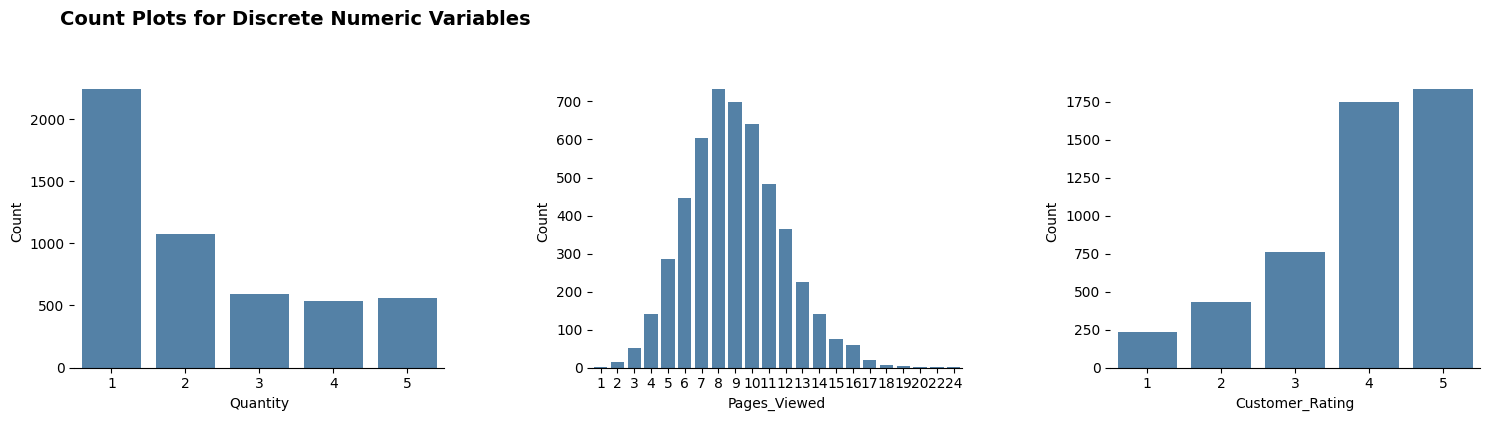

In [51]:
fig,axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(discrete_numeric_cols_purchase):
    sns.countplot(data=df_purchase_experience, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

fig.suptitle("Count Plots for Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1.04, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

- `Quantity` is concentrated at 1 and 2 items, especially 1 item. This means many orders are small purchases.

- `Pages_Viewed` has a count-based distribution that looks roughly bell-shaped. Most sessions are centered around 8 to 10 pages, with fewer sessions at very low or very high page counts. However, because this variable is discrete and bounded, it should be described as approximately normal-like rather than a true normal distribution.

- `Customer_Rating` is concentrated at 4 and 5. This shows that ratings are generally positive, while ratings of 1 and 2 are much less common.

#### **4.5 Boxplots and Outlier Check**

In this step, we use boxplots to check the spread of selected numeric variables and identify visible high-end values or possible outliers. We do not automatically remove outliers because high values can represent real customer purchases, expensive products, larger orders, or longer sessions.

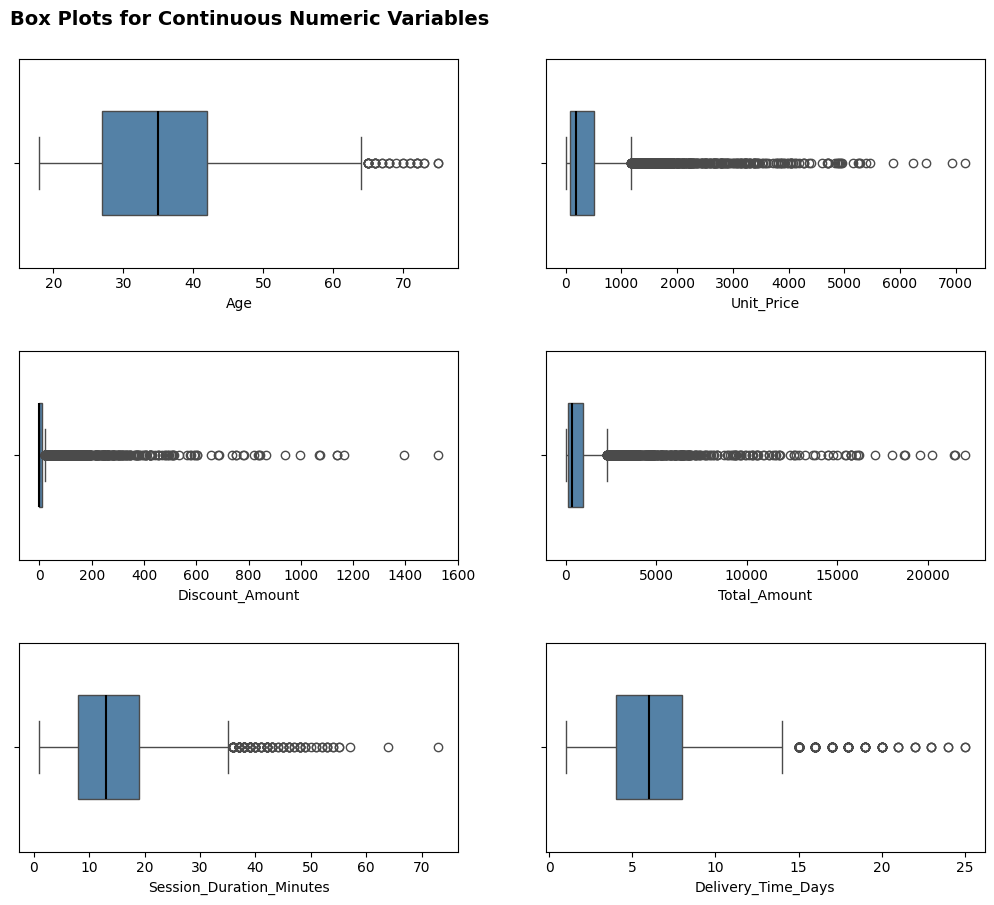

In [52]:
boxplot_cols = ['Age', 'Unit_Price', 'Discount_Amount', 'Total_Amount', 'Session_Duration_Minutes', 'Delivery_Time_Days']
colds = 3   
rows = (len(boxplot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols):
    sns.boxplot(data = df_purchase_experience, x = col, ax = axes[i], color = "steelblue", medianprops={"color": "black", "linewidth": 1.5}, width=0.5)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots for Continuous Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.25)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

The boxplots show visible high-end values in several variables, especially `Unit_Price`, `Discount_Amount`, and `Total_Amount`.

`Age` has a few high-end values, but the maximum age is 75, so these values are realistic. `Session_Duration_Minutes` and `Delivery_Time_Days` also have some higher values, but they are still possible in real customer behavior.

The strongest outlier patterns appear in `Unit_Price`, `Discount_Amount`, and `Total_Amount`. This matches the right-skewed histograms from the previous step.

These values should not be removed automatically because they are not invalid or impossible. They may represent expensive products, larger orders, larger discounts, longer sessions, or slower deliveries.

#### **4.6 Bar Plots for Categorical Variables**

In this step, we use bar plots to check the distribution of important categorical variables. This helps us see whether categories are balanced or dominated by one group.

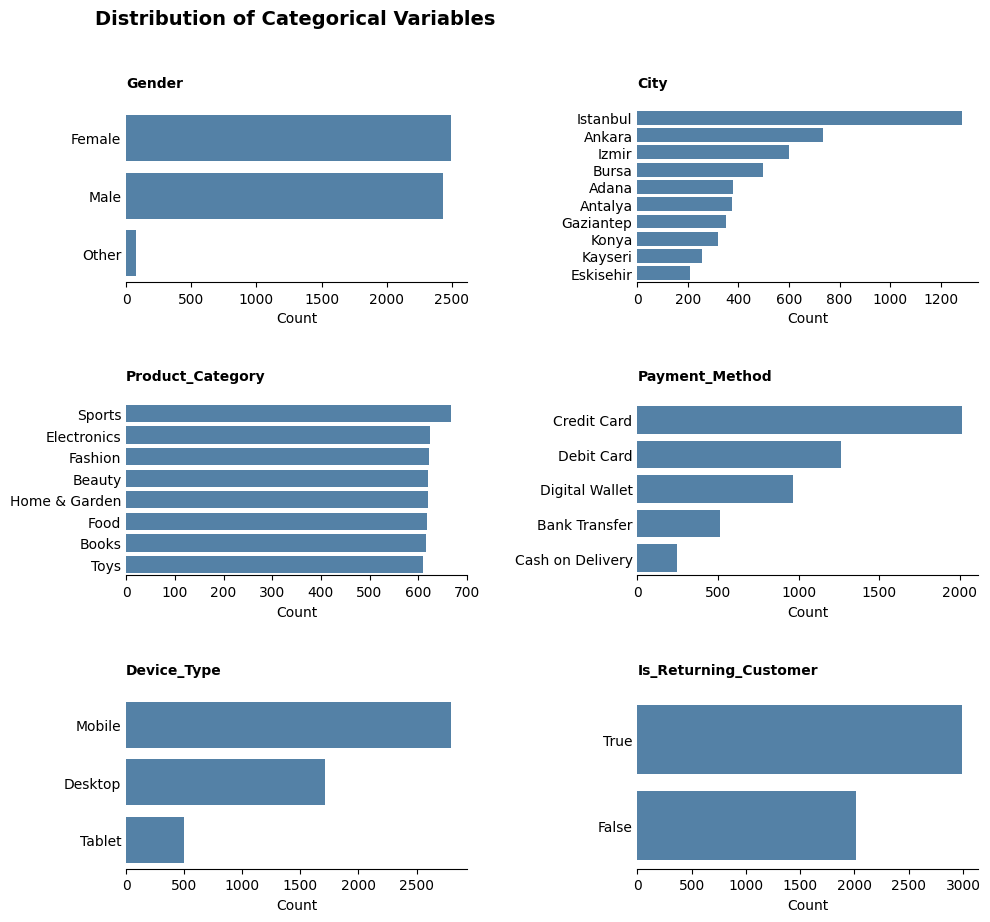

In [53]:
# Bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_purchase) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_purchase):
    order = df_purchase_experience[col].value_counts().index
    
    sns.countplot(data=df_purchase_experience, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=16, fontsize=10, fontweight="bold")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.7)
plt.show();

The categorical bar plots show that some variables are balanced, while others are dominated by a few categories.

`Gender` is mostly balanced between Female and Male, while Other has a much smaller count.

`City` is not evenly distributed. Istanbul has the highest number of records, followed by Ankara and Izmir. The smaller cities have fewer records.

`Product_Category` is very balanced. All product categories have similar counts, so no single category strongly dominates this variable.

`Payment_Method` is more imbalanced. Credit Card is the most common payment method, followed by Debit Card and Digital Wallet. Cash on Delivery is the least common.

`Device_Type` is dominated by Mobile, followed by Desktop. Tablet has the smallest count.

`Is_Returning_Customer` shows that returning customers are more common than new customers in this dataset.

Overall, product categories are balanced, but city, payment method, device type, and returning customer status show clearer imbalance.

#### **4.7 Grouped Distribution Analysis**

In this step, we compare selected numeric variables across meaningful groups. The goal is to see whether purchase behavior, session behavior, or customer experience changes across important categories.

We will only use grouped plots that answer useful business questions.

##### **4.7.1 Customer Rating by Delivery Time Group**

In this step, we compare customer rating across delivery time groups. This helps us see whether slower delivery is related to lower customer satisfaction.

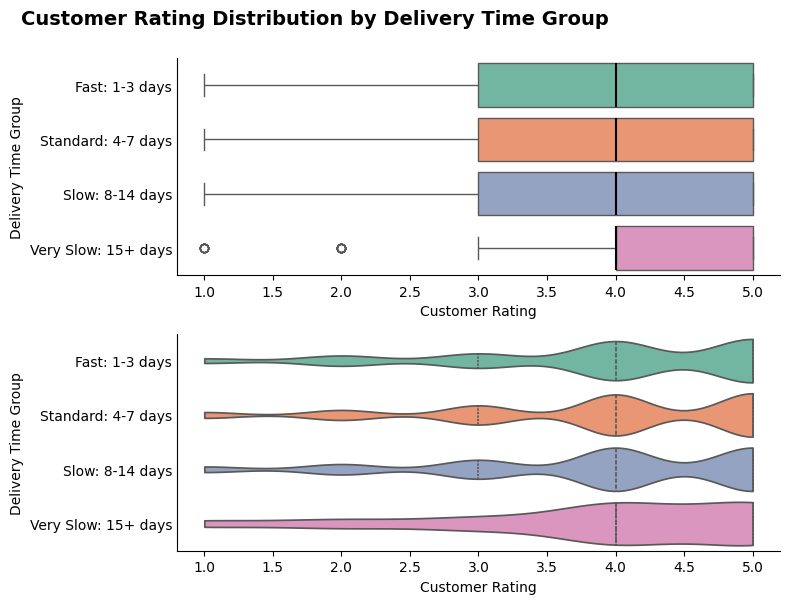

In [54]:
# Create delivery time groups for grouped distribution analysis
delivery_bins = [0, 3, 7, 14, df_purchase_experience["Delivery_Time_Days"].max()]
delivery_labels = ["Fast: 1-3 days", "Standard: 4-7 days", "Slow: 8-14 days", "Very Slow: 15+ days"]
Delivery_Time_Group = pd.cut(df_purchase_experience["Delivery_Time_Days"],bins=delivery_bins,labels=delivery_labels,include_lowest=True)

fig, axes = plt.subplots(2,1,figsize=(8, 6))
axes = axes.flatten()

# KDE plot
sns.boxplot(data=df_purchase_experience,x="Customer_Rating",y=Delivery_Time_Group,hue=Delivery_Time_Group,ax=axes[0], palette="Set2", medianprops={"color": "black", "linewidth": 1.5})

axes[0].set_xlabel("Customer Rating")
axes[0].set_ylabel("Delivery Time Group")
axes[0].tick_params(axis="y", length=0)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_purchase_experience,x="Customer_Rating",y=Delivery_Time_Group, hue=Delivery_Time_Group,ax=axes[1], inner="quartile", cut=0, palette="Set2")

axes[1].set_xlabel("Customer Rating")
axes[1].set_ylabel("Delivery Time Group")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
plt.suptitle("Customer Rating Distribution by Delivery Time Group", fontsize=14, fontweight="bold", y=1, x=0.4)
plt.tight_layout()
plt.show()

Customer ratings look similar across delivery time groups. The median rating is around 4 for all groups, and most ratings are between 3 and 5.

The fast, standard, and slow delivery groups have very similar patterns. The very slow delivery group also has a median around 4, so slower delivery does not show a clear strong drop in customer rating in this plot.

The violin plot is used only to show the general shape of the distribution. Since `Customer_Rating` is a discrete 1-to-5 variable, it should not be interpreted as an exact continuous distribution.

Overall, the groups overlap a lot. Delivery time group does not strongly separate customer rating based on this plot alone.

##### **4.7.2 Total Amount by Product Category**

In this step, we compare total order amount across product categories. This helps us see whether some product categories tend to have higher or lower purchase amounts.

C:\Users\roozb\AppData\Local\Temp\ipykernel_40368\1792379076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_purchase_experience, x="Total_Amount", y="Product_Category", palette="Set2", ax=axes[0],  medianprops={"color": "black", "linewidth": 1.5})
C:\Users\roozb\AppData\Local\Temp\ipykernel_40368\1792379076.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_purchase_experience, x="Total_Amount", y="Product_Category", cut=0, inner="quartile", ax=axes[1], palette="Set2")


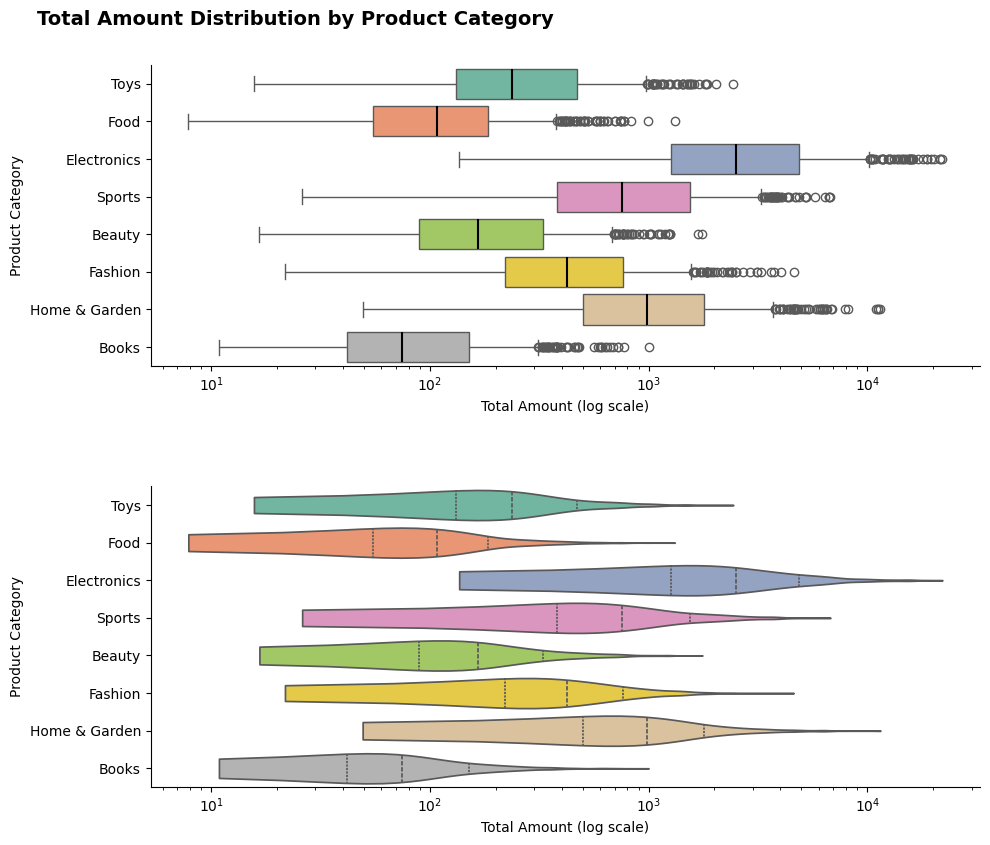

In [55]:
fig, axes = plt.subplots(2,1,figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.boxplot(data=df_purchase_experience, x="Total_Amount", y="Product_Category", palette="Set2", ax=axes[0],  medianprops={"color": "black", "linewidth": 1.5})
axes[0].set_xlabel("Total Amount (log scale)")
axes[0].set_ylabel("Product Category")
axes[0].set_xscale("log")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_purchase_experience, x="Total_Amount", y="Product_Category", cut=0, inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Total Amount (log scale)")
axes[1].set_ylabel("Product Category")
axes[1].set_xscale("log")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
fig.suptitle("Total Amount Distribution by Product Category", fontsize=14, fontweight="bold", y= 1.05, x=0.3)
plt.subplots_adjust(hspace=0.4)
plt.show()

The grouped plots show that `Total_Amount` differs across product categories.

`Electronics` has the highest overall purchase amounts, with a higher median and many high-value orders.  

`Home & Garden` and `Sports` also show relatively higher total amounts compared with several other categories.

`Books` and `Food` have lower total amounts overall. Their distributions are concentrated more in the lower purchase amount range.

Most product categories still show right-skewed patterns and high-end values. This means that even within each category, most orders are smaller, but some orders are much larger.

Because `Total_Amount` is strongly right-skewed, the plot uses a log scale to make the category patterns easier to compare.  

Overall, product category appears to be related to order amount, especially for higher-value categories such as Electronics.

##### **4.7.3 Session Duration by Device Type**

In this step, we compare session duration across device types. This helps us see whether customers spend different amounts of time shopping on Mobile, Desktop, or Tablet.

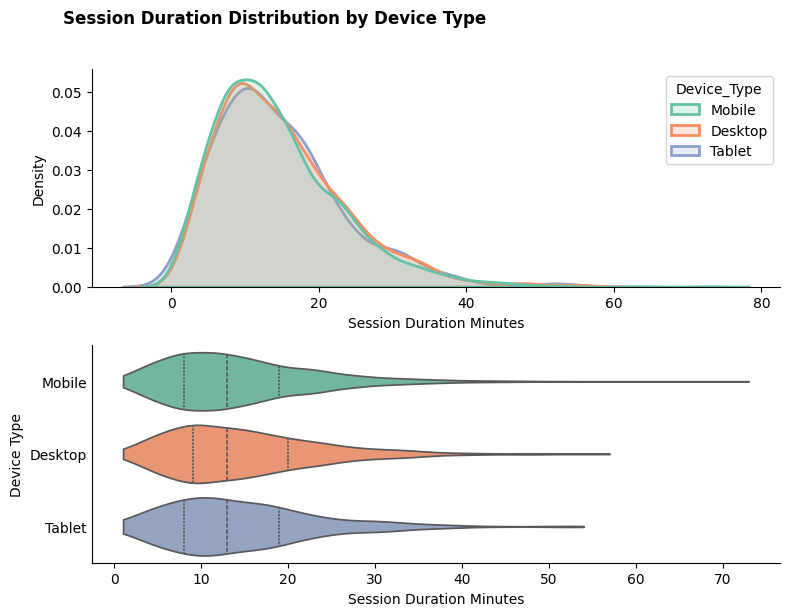

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes = axes.flatten()
# KDE Plot
sns.kdeplot(data=df_purchase_experience,x="Session_Duration_Minutes", hue="Device_Type", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0]) 

axes[0].set_xlabel("Session Duration Minutes")
axes[0].set_ylabel("Density")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_purchase_experience, x="Session_Duration_Minutes",y="Device_Type", hue="Device_Type", inner="quartile",cut=0,ax=axes[1],palette="Set2")

axes[1].set_xlabel("Session Duration Minutes")
axes[1].set_ylabel("Device Type")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
plt.suptitle("Session Duration Distribution by Device Type", fontsize=12, fontweight="bold", y=1.02, x=0.35)
plt.tight_layout()
plt.show()

The session duration distributions look very similar across Mobile, Desktop, and Tablet.

The KDE plot shows that all three device types have a similar right-skewed shape. Most sessions are relatively short, mostly around 8 to 20 minutes, and fewer sessions last much longer.

The violin plot shows the same pattern. The middle range and spread are very close across the three device types. Mobile, Desktop, and Tablet all have longer-session tails, but the overall shapes overlap a lot.

Overall, device type does not strongly separate session duration in this plot. Customers appear to spend similar amounts of time shopping across different device types.

#### **4.8 Final Week 4 Conclusion for Dataset 4**

The Week 4 distribution analysis shows that Dataset 4 is useful for understanding purchase experience, sales behavior, delivery experience, device usage, and customer satisfaction.

The numeric variables do not all follow normal distributions. `Unit_Price`, `Discount_Amount`, and `Total_Amount` are strongly right-skewed. Most transactions are in the lower value range, but some orders have much higher prices, discounts, and total amounts. These high-end values look realistic and should not be removed automatically.

`Age` is mostly concentrated around younger and middle-aged customers, with a right tail up to 75. `Session_Duration_Minutes` and `Delivery_Time_Days` are also right-skewed. Most sessions are relatively short, and most deliveries take around one week, but some sessions and deliveries are longer.

The discrete numeric variables needed count-style plots. `Quantity` is concentrated at 1 and 2 items, showing that many orders are small purchases. `Pages_Viewed` has a roughly bell-shaped count distribution centered around 8 to 10 pages. `Customer_Rating` is concentrated at 4 and 5, which suggests that ratings are generally positive.

The boxplots showed visible high-end values, especially for `Unit_Price`, `Discount_Amount`, and `Total_Amount`. However, these values are not invalid based on the earlier cleaning checks. They may represent expensive products, larger orders, larger discounts, longer sessions, or slower deliveries.

The categorical variables showed mixed balance. `Product_Category` was very balanced across categories. `Gender` was mostly balanced between Female and Male, but Other had a much smaller count. `City`, `Payment_Method`, `Device_Type`, and `Is_Returning_Customer` were more imbalanced. Istanbul, Credit Card, Mobile, and returning customers were the most common groups in their columns.

The grouped distribution analysis showed that delivery time group does not strongly separate customer rating. Ratings were similar across delivery groups, and the median rating was around 4 for all groups. This means slower delivery did not show a clear strong drop in rating based on this plot alone.

`Total_Amount` changed more clearly across product categories. Electronics had the highest purchase amounts, while Books and Food had lower total amounts overall. This suggests that product category is related to order value.

Session duration looked very similar across Mobile, Desktop, and Tablet. The grouped KDE and violin plots showed heavy overlap, so device type does not strongly separate session duration in this dataset.

Overall, Dataset 4 looks usable for analysis. The main points to remember are that sales-related variables are strongly right-skewed, customer ratings are generally positive, product categories are balanced, and grouped plots show both useful differences and heavy overlap depending on the variable.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

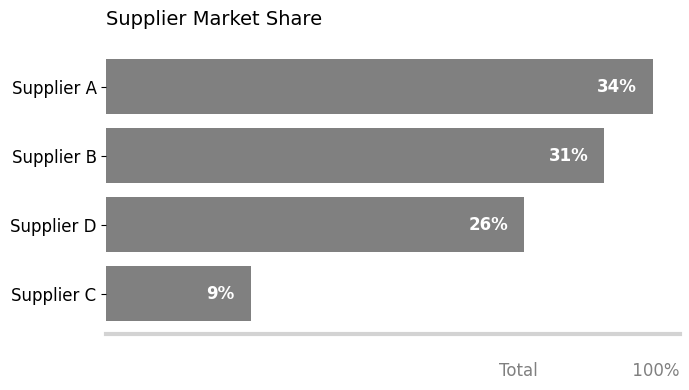

In [57]:
suppliers = ["Supplier A", "Supplier B", "Supplier D", "Supplier C"]
market_share = [34, 31, 26, 9]

plt.figure(figsize=(7, 4))
bars = plt.barh(suppliers, market_share, color="grey")
plt.title("Supplier Market Share", loc="left", fontsize=14, pad=15, y=1)
plt.xticks([])
plt.xlabel("Total                  100%", color="gray", fontsize=12, labelpad=20, loc="right")
plt.yticks(fontsize=12)

# Add percentage labels inside bars
for i, value in enumerate(market_share):
    plt.text(value - 1, i, f"{value}%",va="center", ha="right",color="white",fontsize=12,fontweight="bold")

# Clean style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("lightgray")
ax.spines["bottom"].set_linewidth(3)

# Put Supplier A at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()
